In [2]:
# Standard library

from pathlib import Path
from typing import Any
from itertools import compress
from operator import itemgetter
from itertools import product
from tqdm import tqdm

# Math
import numpy as np
from numpy import array, deg2rad, mean, ndarray, pi, stack, deg2rad
from numpy.random import seed, standard_normal
from scipy.stats import norm, uniform

# Data Handling
import utm
import pandas as pd
from filterpy.monte_carlo import systematic_resample, stratified_resample

# Other Third Party
from rich.progress import track

# Plotting
import matplotlib
from matplotlib import pyplot as plt
from seaborn import move_legend
from svgpath2mpl import parse_path
from svgpathtools import svg2paths
import seaborn as sns

# ProMis
from promis import ProMis, DeltaStaRMap
from promis.geo import (
    CartesianCollection,
    DeltaGrid,
    CartesianDeltaCollection,
    CartesianLocation,
    CartesianMap,
    CartesianRasterBand,
    PolarCollection,
    PolarLocation,
    BufferedPolarPolygon,
    BufferedPolygon,
    BufferedCartesianPolygon, 
    CartesianPolyLine,
)
from promis.geo.helpers import calculate_street_width
from promis.loaders import OsmLoader



In [3]:
# This will auto-relead changed ProMis imports
%reload_ext autoreload
%autoreload 2

# The inD Dataset
https://levelxdata.com/ind-dataset/

https://levelxdata.com/wp-content/uploads/2024/03/inD-Format_1_1.pdf

- verschieben der Karte entsprechend der Umgebung
- anpassen der Weite
- für jede situation, (groupby frame?) berechne eine landscape, in der alle agenten verzeichnet sind.
- wir selbst stehen in der Mitte. Unser Heading / speed ist lowkey egal dafür? vielleicht auch hierzu nochmal mit / ohne experimente machen.

In [4]:
data_path = Path(".") / "data" / "inD-dataset-v1.1" / "data"
# inD_index = "08"

# setting = f"inD-crossing-{inD_index}"
output_folder = Path(".") / "ground-cofi-exports" / "all"
output_folder.mkdir(exist_ok=True, parents=True)

uam_path = output_folder / "uam" / "clean"
star_path = output_folder / "star" / "clean"
promis_path = output_folder / "promis" / "clean"

for path in [uam_path, star_path, promis_path]:
    path.mkdir(exist_ok=True)


In [5]:
def load_inD_data(inD_index: str):
    metadata = pd.read_csv(data_path / f"{inD_index}_recordingMeta.csv", sep=',')
    car_data = pd.read_csv(data_path / f"{inD_index}_tracks.csv", sep=',')
    car_metadata = pd.read_csv(data_path / f"{inD_index}_tracksMeta.csv", sep=',')
    assert metadata["recordingId"].unique() == car_data["recordingId"].unique() == car_metadata["recordingId"].unique()

    # naive center of the scene, but not our origin of coordinates
    # we use this as a bootstrap
    origin = PolarLocation(
        latitude=metadata["latLocation"][0], longitude=metadata["lonLocation"][0]
    )

    # the dataset uses a local coordinate frame based on the UTM projection.
    # the local frame resembles a CartesianCollection, we just need to transform its origin point
    utm_number = utm.latlon_to_zone_number(origin.latitude, origin.longitude)
    utm_letter = utm.latitude_to_zone_letter(origin.latitude)

    origin_coords = utm.to_latlon(
        easting=metadata["xUtmOrigin"][0],
        northing=metadata["yUtmOrigin"][0],
        zone_number=utm_number,
        zone_letter=utm_letter,
    )
    origin = PolarLocation(longitude=origin_coords[1], latitude=origin_coords[0])

    x_utm = car_data["xCenter"] + metadata["xUtmOrigin"][0]
    y_utm = car_data["yCenter"] + metadata["yUtmOrigin"][0]
    polar_car_coords = np.array(
        [utm.to_latlon(x, y, utm_number, utm_letter) for x,y in zip(x_utm, y_utm)]
    )[:, ::-1] # polar coordinates are parsed longitude first, but the conversion returns coordinates in reverse order
    polar_car_coord_collection = PolarCollection(origin)
    polar_car_coord_collection.append_with_default(polar_car_coords, 0)
    cartesian_car_cords = polar_car_coord_collection.to_cartesian().coordinates()

    car_data["xCenter_utm"] = car_data["xCenter"]
    car_data["yCenter_utm"] = car_data["yCenter"]
    car_data["xCenter"] = cartesian_car_cords[:, 0] 
    car_data["yCenter"] = cartesian_car_cords[:, 1] 

    # we now want to translate the origin to the approximate center of the scene
    # that way, we avoid to compute lots of uninteresting points
    bounds = [[car_data[row].max(), car_data[row].min()] for row in ["xCenter", "yCenter"]]
    offsets = [mean(bound_pair) for bound_pair in bounds]
    diameter = np.ceil( max([bound_pair[0] - bound_pair[1] for bound_pair in bounds]) / 10) * 10

    origin = CartesianLocation(*offsets).to_polar(origin)
    dimensions = width, height = diameter, diameter

    collection = CartesianDeltaCollection(origin=origin, number_of_values=0)
    car_data["xCenter"] = car_data["xCenter"] - offsets[0]
    car_data["yCenter"] = car_data["yCenter"] - offsets[1]
    car_data["speed"] = np.sqrt(np.pow(car_data["xVelocity"], 2) + np.pow(car_data["yVelocity"], 2)) * 3.6
    car_data = car_data.join(car_metadata[["trackId", "class"]], on="trackId", how="left", rsuffix="r", validate="m:1")
    del car_data["trackIdr"]

    collection.append_with_default(car_data[["xCenter", "yCenter", "heading", "speed"]].values, value=())
    dt = 1 / metadata["frameRate"]
    

    return car_data, collection, origin, dimensions, dt

In [6]:
feature_description = {
    "primary": "['highway' = 'primary']",
    "secondary": "['highway' = 'secondary']",
    "tertiary": "['highway' = 'tertiary']",
    "service": "['highway' = 'service']",
    "residential": "['highway' = 'residential']",
    "crossing": "['footway' = 'crossing']",
    "living_street": "[highway=living_street]",
    "unclassified": "['highway' = 'unclassified']",
    "signal": "['highway' = 'traffic_signals']",
    "stop_sign": "['highway' = 'stop']",
    "footway": "['highway' = 'footway']",
}

covariance = {
    "primary": 2 * np.eye(2),
    "secondary": 3 * np.eye(2),
    "tertiary": 3 * np.eye(2),
    "residential": 3 * np.eye(2),
    "living_street": 3 * np.eye(2),
    "service": 4 * np.eye(2),
    "unclassified": 3 * np.eye(2),
}

covariance |= {
    f"left_{key}": covariance[key]
    for key in covariance.keys()
} | {
    f"right_{key}": covariance[key]
    for key in covariance.keys()
}
covariance |= {
    "intersection": 2 * np.eye(2),
    "crossing": 2 * np.eye(2),
    "signal": 2*np.eye(2),
    "footway": 2*np.eye(2),
}

In [7]:
road_types = [
    "secondary",
    "tertiary",
    "residential",
    "unclassified",
    "living_street",
]

In [8]:
def entire_logic(
    likelihood_crossing = 0.2,
    likelihood_yield = 0.45,
    likelihood_stop = 0.9,
    disobedience_speed = 0.1,
    agent_type = "any",
) -> str:
    return f"""
% constitution for agent type {agent_type}

{str(likelihood_crossing)[:5]}::expect_halt(X) :- crosses(X, crossing).
{str(likelihood_yield)[:5]}::expect_halt(X) :- crosses(X, yield).
{str(likelihood_stop)[:5]}::expect_halt(X) :- crosses(X, stop).

obeys_halts(X) :- 
    \+ expect_halt(X);
    expect_halt(X), halts(X).

halts(X) :- 
    state_speed(X, S),
    S =< 20.

obeys_speed_limit(X) :-
    state_speed(X, S),
    S =< 50.

{str(disobedience_speed)[:5]}::obeys_speed_limit(X) :-
    state_speed(X, S),
    S >= 50.

0.90::on_correct_side(X, LocationType) :- 
    follows(X, LocationType),
    over(X, right, LocationType);
    \+ follows(X, LocationType),
    over(X, left, LocationType).

side_correct(X) :-
    on_correct_side(X, secondary);
    on_correct_side(X, tertiary);
    on_correct_side(X, residential);
    on_correct_side(X, living_street);
    on_correct_side(X, unclassified).

side_correct(X) :- distance(X, intersection) < 10.

landscape(X) :- 
    obeys_halts(X),
    side_correct(X),
    obeys_speed_limit(X).
        
    """ + \
    "\n".join([f"""over(X, right, {key}) :- over(X, right_{key}). 
    over(X, left, {key}) :- over(X, left_{key}).""" for key in road_types])


entire_logic_requirements = "\n".join([
f"""over(X, left_{key})
over(X, right_{key})
angle(X, {key})
follows(X, {key})
""" for key in road_types
]) + """
distance(X, intersection)
crosses(X, crossing)
crosses(X, stop)
crosses(X, yield)
"""

In [119]:
def reduce_logic(
    likelihood_crossing = 0.2,
    likelihood_yield = 0.45,
    likelihood_stop = 0.9,
    disobedience_speed = 0.1,
    agent_type = "any",
) -> str:
    return f"""
% constitution for agent type {agent_type}

{str(likelihood_crossing)[:5]}::expect_halt(X) :- crosses(X, crossing).
{str(likelihood_yield)[:5]}::expect_halt(X) :- crosses(X, yield).
{str(likelihood_stop)[:5]}::expect_halt(X) :- crosses(X, stop).

obeys_halts(X) :- 
    \+ expect_halt(X);
    expect_halt(X), halts(X).

halts(X) :- 
    state_speed(X, S),
    S =< 20.

obeys_speed_limit(X) :-
    state_speed(X, S),
    S =< 50.

{str(disobedience_speed)[:5]}::obeys_speed_limit(X) :-
    state_speed(X, S),
    S >= 50.

landscape(X) :- 
    obeys_halts(X),
    obeys_speed_limit(X).
        
    """

In [9]:
# intersections are unmarked in OSM. As per the wiki, Intersections are represented using shared nodes.
# we therefore use a preprocessor that checks every node with every other node to see wether they are close
def fetch_intersections(
        uam: CartesianMap, 
        number_of_arms = 3, 
        intersection_location_type="intersection", 
        delta = 0.01,
    ) -> list[CartesianLocation]:

    intersection_points: list[CartesianLocation] = []
    for feature_index, feature in enumerate(uam.features):
        if not isinstance(feature, BufferedPolygon): # only buffered ways could be roads that intersect
            continue
        feature_locs = feature.polyline.to_polar().to_cartesian(uam.origin).to_numpy()
        num_close_points = np.zeros(feature_locs.shape[0])
        

        for other_feature_index, other_feature in enumerate(uam.features[feature_index+1:]):
            if not isinstance(other_feature, BufferedPolygon): # only buffered ways could be roads that intersect
                continue
            other_locs = other_feature.polyline.to_polar().to_cartesian(uam.origin).to_numpy()
            feature_mat = np.atleast_3d(feature_locs).repeat(other_locs.shape[0], axis=2)
            other_mat = np.atleast_3d(other_locs).repeat(feature_locs.shape[0], axis=2).transpose((2, 1, 0))
            # mat axes: 0-len(features); 1-2; 2-len(other_features)

            dists = np.sqrt(np.pow(feature_mat-other_mat, 2).sum(axis=1))
            num_close_points += np.sum(dists < delta, axis=1)
            
        new_points = compress(feature.polyline.locations, num_close_points >= number_of_arms - 1)
        intersection_points.extend(
            [new_point for new_point in new_points 
            if not any([new_point.distance(old_point) < delta for old_point in intersection_points])]
        )
    return [CartesianLocation(east=loc.east,
        north=loc.north,
        location_type=intersection_location_type,
        name=loc.name,
        origin=uam.origin,
    ) for loc in intersection_points]

In [10]:
def build_uam(origin, dimensions, inD_index:str, covariance):
    uam = OsmLoader(
        origin=origin,
        dimensions=dimensions,
        feature_description=feature_description,
        polygonize_routes=True,
        timeout=5,
    ).to_cartesian_map()
    uam.features.extend(fetch_intersections(uam))
    uam.apply_covariance(covariance)
    
    uam.save(uam_path / f"uam-{inD_index}.pkl")


In [11]:
def plot_traj_shift(cars):
    fig, ax = plt.subplots(1, 1, figsize=(7,7))
    for feature_index, df in enumerate([cars]):
        for trackId in df["trackId"].unique():
            track = df[df["trackId"] == trackId]
            ax.plot(track["xCenter"], track["yCenter"], alpha = 0.3, color = "red")
            ax.plot(track["xCenter_utm"], track["yCenter_utm"], alpha = 0.3, color = "blue")


In [12]:
def build_star(origin, dimensions, inD_index: str, logic, dt=1):
    width, height = dimensions
    uam = CartesianMap.load(uam_path.parent / "preprocessed" / f"uam-pp-{inD_index}.pkl")
    support = DeltaGrid(origin, (40, 40), width, height, speed_res=7, speed_bounds=(5, 65), bearing_res=13)
    dsm = DeltaStaRMap(uam, dt)
    dsm.initialize(support, 20, logic)
    dsm.save(star_path / f"star-{inD_index}-{dt}s.pkl")

In [13]:
def build_landscape(origin, dimensions, logic, logic_name, inD_index, dt):
    width, height = dimensions
    dsm = DeltaStaRMap.load(star_path / f"star-{inD_index}-{dt}s.pkl")
    promis = ProMis(dsm)
    support = DeltaGrid(origin, (40, 40), width, height, speed_res=7, speed_bounds=(5, 65), bearing_res=13)    
    promis.solve(support, logic, print_first=True, show_progress=True, n_jobs=8, batch_size=10)
    support.save(promis_path / f"landscape-{inD_index}-{dt}s--{logic_name}.pkl")

## Putting it all together

In [14]:
index_list = [f"0{str(i)}" for i in range(10)] + [str(i) for i in range(10, 32)]

In [15]:
group00 = index_list[:7]
group07 = index_list[7:18]
group18 = index_list[18:30]
group30 = index_list[30:]

used_index = {i: "00" for i in group00} \
    | {i: "07" for i in group07} \
    | {i: "18" for i in group18} \
    | {i: "30" for i in group30}

index_shortlist = ["00", "07", "18", "30"]

In [16]:
dimensions_per_index = {}
for index in index_shortlist:
    _, _, _, dimensions, _ = load_inD_data(index)
    dimensions_per_index[index] = dimensions
dimensions_per_index

{'00': (np.float64(130.0), np.float64(130.0)),
 '07': (np.float64(70.0), np.float64(70.0)),
 '18': (np.float64(90.0), np.float64(90.0)),
 '30': (np.float64(90.0), np.float64(90.0))}

In [ ]:
for inD_index in index_shortlist:
    _, _, origin, dimensions, dt = load_inD_data(inD_index)
    build_uam(origin, dimensions, inD_index, covariance)


In [15]:
logic = entire_logic()
logic_name = "constitution"
logic_requirements = entire_logic_requirements

In [17]:
uam00 = CartesianMap.load(uam_path /  f"uam-00.pkl")
uam07 = CartesianMap.load(uam_path /  f"uam-07.pkl")
uam18 = CartesianMap.load(uam_path /  f"uam-18.pkl")
uam30 = CartesianMap.load(uam_path /  f"uam-30.pkl")


uam00_extras = {
    "crossing": [[40, -10], [35, 10]],
    "crossing": [[25, 20], [15, 18]],
    "crossing": [[0, 0], [10, -18]],
    "yield": [[25, 20], [20, 20]],
}
# crossing 40, -10 zu 35, 10
# crossing 25 , 20 zu 15, 18
# crossing 0,0 zu 10, -18
# yield 25, 20 - 20, 20

uam07_extras = {
    "stop": [[10, 10], [15, 5]],
    "yield": [[-5, -20], [-10, -15]],
}
# stop 10, 10 zu 15, 5
# yield -5, -20 zu -10, -15 

uam18_extras = {
    "crossing": [[10, 10], [10, -5]],
}
# crossing 10, 10 zu 10, -5
uam30_extras = {
    "stop": [[0, 10], [-5, 5]],
}

labels = ["00", "07", "18", "30"]
i = 0
for uam, extras in [
    (uam00, uam00_extras),
    (uam07, uam07_extras),
    (uam18, uam18_extras),
    (uam30, uam30_extras),
]:
    print(set([f.location_type for f in uam.features]))
    for location_type, coords in extras.items():
        uam.features.append(
            CartesianPolyLine(
                [ CartesianLocation(x, y) for x, y in coords],
                location_type=location_type,
                covariance= 4 * np.eye(2),
                origin=uam.origin,
            )
        )
    uam.save(uam_path.parent / "preprocessed" / f"uam-pp-{labels[i]}.pkl")
    i += 1

{'left_footway', 'left_service', 'intersection', 'footway', 'left_tertiary', 'tertiary', 'right_unclassified', 'right_tertiary', 'left_unclassified', 'right_footway', 'right_service', 'unclassified', 'service'}
{'left_service', 'intersection', 'left_tertiary', 'tertiary', 'right_unclassified', 'right_tertiary', 'left_unclassified', 'right_service', 'unclassified', 'service'}
{'right_residential', 'left_footway', 'residential', 'left_residential', 'footway', 'right_footway', 'intersection'}
{'left_footway', 'left_service', 'crossing', 'left_crossing', 'secondary', 'right_crossing', 'footway', 'intersection', 'right_secondary', 'left_secondary', 'living_street', 'right_living_street', 'right_footway', 'left_living_street', 'right_service', 'service'}


In [ ]:
for inD_index in index_shortlist[:]:
    uam = CartesianMap.load(uam_path.parent / "preprocessed" / f"uam-pp-{inD_index}.pkl")
    origin, dimensions = uam.origin, dimensions_per_index[inD_index]
    build_star(origin, dimensions, inD_index, entire_logic_requirements, dt=1.5)

In [ ]:
for inD_index in index_shortlist[:]:
    uam = CartesianMap.load(uam_path.parent / "preprocessed" / f"uam-pp-{inD_index}.pkl")
    origin, dimensions = uam.origin, dimensions_per_index[inD_index]
    build_star(origin, dimensions, inD_index, entire_logic_requirements, dt=3)

In [ ]:
for inD_index in index_shortlist[:]:
    uam = CartesianMap.load(uam_path.parent / "preprocessed" / f"uam-pp-{inD_index}.pkl")
    origin, dimensions = uam.origin, dimensions_per_index[inD_index]
    build_landscape(origin, dimensions, entire_logic(), logic_name, inD_index, dt=3)

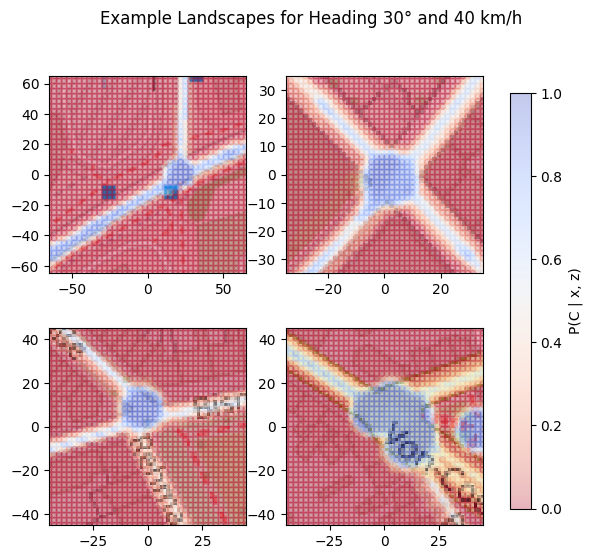

In [268]:
fig, axes = plt.subplots(2, 2, figsize=(7, 6))
b = 30
s = 40
for i, inD_index in enumerate(index_shortlist):

    #landscape = DeltaStaRMap.load(star_path / f"star-{inD_index}-3s.pkl").get("crosses", "yield").parameters
    landscape = CartesianDeltaCollection.load(promis_path / f"landscape-{inD_index}-3s--trusted_car2.pkl") 
    im = landscape.scatter(bearing=b, speed=s, s=20, alpha = 0.3, ax = axes[int(i / 2)][i % 2], cmap = "coolwarm_r")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9, label="P(C | x, z)")
fig.suptitle("Example Landscapes for Heading 30° and 40 km/h")
fig.savefig(output_folder / "figures" /"experiments" / "landscapes.pdf")

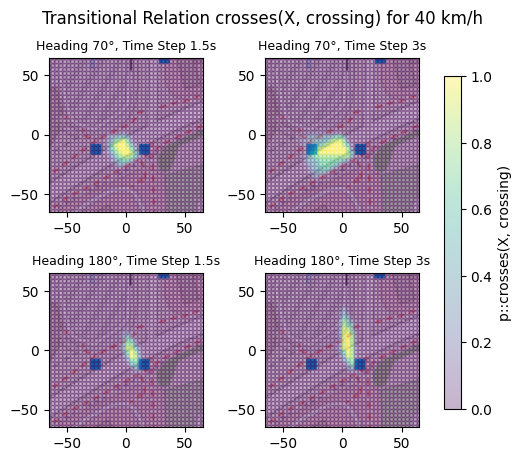

In [281]:
dsm_00_30 = DeltaStaRMap.load(star_path / "star-00-3s.pkl")
dsm_00_15 = DeltaStaRMap.load(star_path / "star-00-1.5s.pkl")

fig, axes = plt.subplots(2, 2)
stars = ["1.5s", "3s"]

for i, dsm_ in enumerate([dsm_00_15, dsm_00_30]):
    crosses_crossing = dsm_.get("crosses", "crossing").parameters
    crosses_crossing.scatter(0, 70, 40, ax=axes[0][i], s=10, alpha=0.3)
    im = crosses_crossing.scatter(0, 180, 40, ax=axes[1][i], s=10, alpha=0.3)
    axes[0][i].set_title(f"Heading 70°, Time Step {stars[i]}", fontsize=9)
    axes[1][i].set_title(f"Heading 180°, Time Step {stars[i]}", fontsize=9)
    

plt.subplots_adjust(hspace=0.4)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9, label="p::crosses(X, crossing)")
fig.suptitle("Transitional Relation crosses(X, crossing) for 40 km/h")
fig.savefig(output_folder / "figures" /"experiments" / "crosses.pdf")

In [ ]:
fig, ax = plt.subplots()
i = "18"
dsm = DeltaStaRMap.load(star_path / f"star-{i}.pkl")
uam = CartesianMap.load(uam_path / f"uam-{i}.pkl")
landscape = CartesianDeltaCollection.load(promis_path / f"landscape-{i}--sides.pkl")

# landscape.scatter(bearing=180, speed = 40, cmap="coolwarm_r")
colors = ["blue", "orange", "green", "red"]


print(uam.features)
for j, f in enumerate(uam.features):
    if isinstance(f, CartesianLocation):
        plt.scatter(*f.to_numpy(), c="black")
    if not isinstance(f, BufferedPolygon):
        continue

    color = colors[j % len(colors)]
    plt.plot(*f.geometry.exterior.xy, c=color)
    plt.scatter(*f.geometry.exterior.xy, c=color)
    
    print(f.name, calculate_street_width(f.polyline), f.location_type)
    
w, h = dimensions_per_index[i]
# plt.xlim(- w / 2, w / 2)
# plt.ylim(- h / 2, h / 2)
plt.xlim(- 20, 20)
plt.ylim(-10, 20)

plt.savefig(output_folder / "figures" / "foundations" / f"map_{i}.svg")
plt.savefig(output_folder / "figures" / "foundations" / f"map_{i}.pdf")

In [ ]:
fig, ax = plt.subplots()
i = "18"
dsm = DeltaStaRMap.load(star_path / f"star-{i}.pkl")
uam = CartesianMap.load(uam_path / f"uam-{i}.pkl")
landscape = CartesianDeltaCollection.load(promis_path / f"landscape-{i}--sides.pkl")

# landscape.scatter(bearing=180, speed = 40, cmap="coolwarm_r")
colors = ["blue", "orange", "green", "red"]

print(uam.features)
for sampled_uam in uam.sample(5):
    for j, f in enumerate(sampled_uam.features):
        if isinstance(f, CartesianLocation):
            plt.scatter(*f.to_numpy(), c="black")
        if not isinstance(f, BufferedPolygon):
            continue
        color = colors[j % len(colors)]
        plt.plot(*f.geometry.exterior.xy, alpha = 0.5, c=color)
        plt.scatter(*f.geometry.exterior.xy, alpha=0.5, c=color)

        print(f.name, calculate_street_width(f.polyline), f.location_type)

w, h = dimensions_per_index[i]
# plt.xlim(- w / 2, w / 2)
# plt.ylim(- h / 2, h / 2)
plt.xlim(- 20, 20)
plt.ylim(-10, 20)

plt.savefig(output_folder / "figures" / "foundations" / f"sampled_map_{i}.svg")
plt.savefig(output_folder / "figures" / "foundations" / f"sampled_map_{i}.pdf")

## Track Preprocessing

In [18]:
def val_test_split(group):
    training_set = pd.DataFrame()
    validation_set = pd.DataFrame()
    test_set = pd.DataFrame()

    for inD_index in group:
        tracks, _, _, _, _ = load_inD_data(inD_index)
        tracks = tracks[tracks["class"].isin(["car", "truck_bus", "bicycle"])]
        tracks["group"] = inD_index
        tracks["trackId"] = inD_index + "-" + tracks["trackId"].astype(pd.StringDtype())

        ids = tracks["trackId"].unique()

        val_start_i, test_start_i = int(0.5 * len(ids)), int(0.7 * len(ids))
        training_part = ids[15:val_start_i] # the first ten, fifteen cars are parking
        validation_part = ids[val_start_i:test_start_i]
        test_part = ids[test_start_i:]

        training_set = pd.concat([training_set, tracks[tracks["trackId"].isin(training_part)]], ignore_index=True)
        validation_set = pd.concat([validation_set, tracks[tracks["trackId"].isin(validation_part)]], ignore_index=True)
        test_set = pd.concat([test_set, tracks[tracks["trackId"].isin(test_part)]], ignore_index=True)
    return training_set, validation_set, test_set

In [19]:
splits = { 
    env_index: val_test_split(group) 
    for env_index, group in [("00", group00), ("07", group07), ("18", group18), ("30", group30)]
}

In [91]:
train_set, validation_set, test_set = splits["00"]

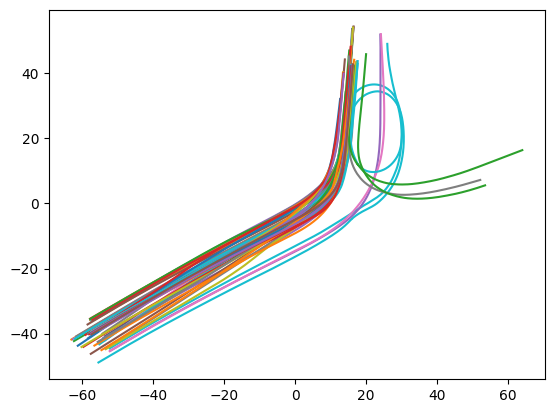

In [92]:
def find_trajectories_in(trajectory_set: pd.DataFrame, x_bbox, y_bbox, type):
    trajectory_set = trajectory_set[trajectory_set["class"] == type]
    bbox_tracks = trajectory_set[
        (trajectory_set["xCenter"] > x_bbox[0]) & 
        (trajectory_set["xCenter"] < x_bbox[1]) & 
        (trajectory_set["yCenter"] > y_bbox[0]) & 
        (trajectory_set["yCenter"] < y_bbox[1])
    ]["trackId"]

    return trajectory_set[trajectory_set["trackId"].isin(bbox_tracks)]

some_curves = find_trajectories_in(validation_set, x_bbox=(10, 25), y_bbox=(15, 25), type="car")

for trackId in some_curves["trackId"].unique():
    track = some_curves[some_curves["trackId"] == trackId]
    plt.plot(track["xCenter"], track["yCenter"])


In [80]:
from sklearn.metrics import mean_absolute_error, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.preprocessing import OneHotEncoder, RobustScaler

halt_reg_one = MLPClassifier(
    hidden_layer_sizes=(150,),
    activation="relu",
    alpha=1e-3,  # L2 regularization
    solver="adam",
    max_iter=1_000,
    random_state=2026,
    tol=1e-3,
    verbose=True,
)

halt_reg = BaggingClassifier(
    estimator=halt_reg_one,
    n_estimators=20, 
    bootstrap=True,
)

In [81]:
downsample = 2

global halt_reg_X_df
halt_reg_X_df = pd.DataFrame(columns=splits["00"][0].columns)
for env_index in index_shortlist:
    df_input = splits[env_index][0][::downsample].copy()
    star = DeltaStaRMap.load(star_path / f"star-{env_index}-3s.pkl")

    for location_type in ["stop", "yield", "crossing"]:
        crosses = star.get("crosses", location_type).parameters.get_interpolator()
        crosses = crosses(df_input[["xCenter", "yCenter", "heading", "speed"]])[:, 0]
        crosses = crosses > 0.5
        df_input[location_type] = crosses

    halt_reg_X_df = pd.concat([halt_reg_X_df, df_input])

agent_type_name = halt_reg_X_df["class"].to_numpy().reshape(-1, 1)
length = halt_reg_X_df["length"].fillna(0).to_numpy().reshape(-1, 1)

one_hot_agent_type = OneHotEncoder()
one_hot_agent_type.fit(agent_type_name)

length_scaler = RobustScaler()
length_scaler.fit(length)


speed_reg_X = np.concatenate(
    [
        one_hot_agent_type.transform(agent_type_name).toarray(),
        length_scaler.transform(length), 
        halt_reg_X_df["stop"].to_numpy().reshape(-1, 1),
        halt_reg_X_df["yield"].to_numpy().reshape(-1, 1),
        halt_reg_X_df["crossing"].to_numpy().reshape(-1, 1),
    ],
    axis=1,
)

halt_reg_y = halt_reg_X_df["speed"] < 20

/tmp/ipykernel_406506/3474701729.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  halt_reg_X_df = pd.concat([halt_reg_X_df, df_input])


In [82]:
X_train, X_test, y_train, y_test = train_test_split(speed_reg_X, halt_reg_y, random_state=2026)

In [ ]:
halt_reg.fit(X_train, y_train)

Iteration 1, loss = 0.43479136
Iteration 2, loss = 0.43275300
Iteration 3, loss = 0.43236405
Iteration 4, loss = 0.43194278
Iteration 5, loss = 0.43185870
Iteration 6, loss = 0.43162512
Iteration 7, loss = 0.43128064
Iteration 8, loss = 0.43104261
Iteration 9, loss = 0.43088983
Iteration 10, loss = 0.43083686
Iteration 11, loss = 0.43054529
Iteration 12, loss = 0.43031543
Iteration 13, loss = 0.42994984
Training loss did not improve more than tol=0.001000 for 10 consecutive epochs. Stopping.
Iteration 1, loss = 0.43549147
Iteration 2, loss = 0.43276344
Iteration 3, loss = 0.43248054
Iteration 4, loss = 0.43222597
Iteration 5, loss = 0.43194320
Iteration 6, loss = 0.43169673
Iteration 7, loss = 0.43159055
Iteration 8, loss = 0.43131125
Iteration 9, loss = 0.43106530
Iteration 10, loss = 0.43098660
Iteration 11, loss = 0.43064168
Iteration 12, loss = 0.43047704
Iteration 13, loss = 0.43021599
Training loss did not improve more than tol=0.001000 for 10 consecutive epochs. Stopping.
Iterat

,estimator,MLPClassifier... verbose=True)
,n_estimators,20
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [24]:
from pickle import dump
with open(output_folder / "rule_likelihood_classifier.pkl", "wb") as f:
    dump(halt_reg, f)

In [25]:
mean_absolute_error(y_train, halt_reg.predict(X_train))

0.16544759976200554

In [26]:
mean_absolute_error(y_test, halt_reg.predict(X_test))

0.16614041787136544

In [27]:
accuracy_score(y_test, halt_reg.predict(X_test))

0.8338595821286345

In [28]:
trust_in_rules = []
for agent_type in ["car", "truck_bus", "bicycle"]:
    print(agent_type)
    one_hot_agent_rep = one_hot_agent_type.transform(array(agent_type).reshape(1, -1)).toarray()
    one_hot_agent_rep = one_hot_agent_rep[0, :]
    
    mean_len_agent = halt_reg_X_df[halt_reg_X_df["class"] == agent_type]["length"].mean()
    
    pstop = halt_reg.predict_proba(array([*one_hot_agent_rep, mean_len_agent, 1, 0, 0]).reshape(1, -1))[0][1]
    pyield = halt_reg.predict_proba(array([*one_hot_agent_rep, mean_len_agent, 0, 1, 0]).reshape(1, -1))[0][1]
    pcrossing = halt_reg.predict_proba(array([*one_hot_agent_rep, mean_len_agent, 0, 0, 1]).reshape(1, -1))[0][1]

    trust_in_rules.append([agent_type, "stop", pstop])
    trust_in_rules.append([agent_type, "yield", pyield])
    trust_in_rules.append([agent_type, "crossing", pcrossing])

halt_rule_trusts = pd.DataFrame(
    columns=["agent_type", "location_type", "prob_halt"], 
    data = trust_in_rules,
)
halt_rule_trusts

car
truck_bus
bicycle


,agent_type,location_type,prob_halt
0,car,stop,0.101236
1,car,yield,0.333881
2,car,crossing,0.053253
3,truck_bus,stop,0.087324
4,truck_bus,yield,0.229133
5,truck_bus,crossing,0.067620
6,bicycle,stop,0.214829
7,bicycle,yield,0.560864
8,bicycle,crossing,0.095580


,agent_type,env_index,p_faster_50
0,car,00,0.53214
1,truck_bus,00,0.20741
2,bicycle,00,0.07688
3,car,07,0.04115
4,truck_bus,07,0.00072
5,bicycle,07,0.00410
6,car,18,0.00002
7,truck_bus,18,0.00000
8,bicycle,18,0.00002
9,car,30,0.19416


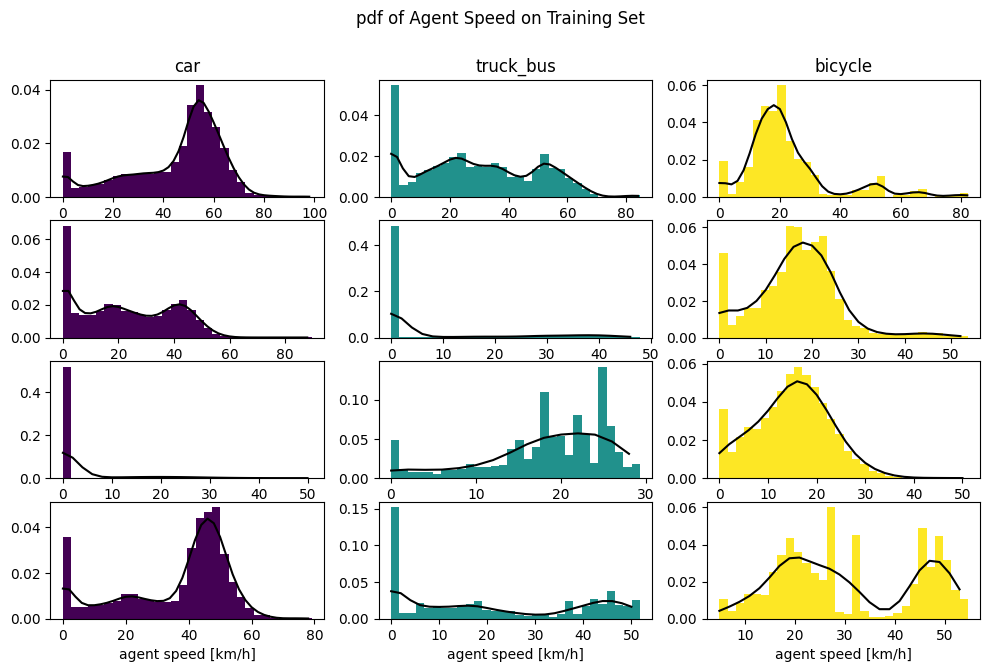

In [29]:
from sklearn.neighbors import KernelDensity

fig, ax = plt.subplots(4, 3, figsize=(12, 7))
faster_50 = []
for i, env_index in enumerate(index_shortlist):
    x = splits[env_index][0][::1]
    for j, agent_type in enumerate(["car", "truck_bus", "bicycle"]):
        x_ = x[x["class"] == agent_type]["speed"].to_numpy()
        ax[0][j].title.set_text(agent_type)
        ax[3][j].xaxis.label.set_text("agent speed [km/h]")
        ax[i][j].hist(x_, bins=30, color=matplotlib.colormaps["viridis"](j / 2), density = True)
        kde = KernelDensity(bandwidth=3, )
        kde.fit(x_.reshape(-1, 1))
        
        x_plot = np.arange(x_.min(), x_.max(), 2).reshape(-1, 1)
        log_dens = kde.score_samples(x_plot)
        ax[i][j].plot(
            x_plot[:, 0],
            np.exp(log_dens),
            color="black",
        )

        n_samples = 100000
        samples = kde.sample(n_samples)
        faster_50.append([agent_type, env_index, (samples > 50).mean()])

fig.suptitle("pdf of Agent Speed on Training Set")
faster_50 = pd.DataFrame(
    columns=["agent_type", "env_index", "p_faster_50"],
    data=faster_50,
)

plt.savefig(output_folder / "figures" / "experiments" / f"speed_pdf.svg")
plt.savefig(output_folder / "figures" / "experiments" / f"speed_pdf.pdf")

faster_50

In [30]:
faster_50.to_csv(output_folder / "rule_50_probs.csv")
halt_rule_trusts.to_csv(output_folder / "rule_likelihoods_probs.csv")

In [71]:
faster_50 = pd.read_csv(output_folder / "rule_50_probs.csv")
halt_rule_trusts = pd.read_csv(output_folder / "rule_likelihoods_probs.csv")

faster_50.to_latex(output_folder / "rule_50_probs.tex", columns=["agent_type", "env_index", "p_faster_50"])
halt_rule_trusts.to_latex(output_folder / "rule_likelihoods_probs.tex", columns=["agent_type", "location_type", "prob_halt"])

In [85]:
from pickle import load
from sklearn.metrics import confusion_matrix
with open(output_folder / "rule_likelihood_classifier.pkl", 'rb') as f:
    halt_reg = load(f)
confusion_matrix(y_test, halt_reg.predict(X_test))

array([[  8359,  74048],
       [  2090, 373778]])

In [ ]:
# compute full logic for every agent
for inD_index in index_shortlist[:]:
    uam = CartesianMap.load(uam_path.parent / "preprocessed" / f"uam-pp-{inD_index}.pkl")
    origin, dimensions = uam.origin, dimensions_per_index[inD_index]
    for agent_type in ["car", "truck_bus", "bicycle"]:
        likelihoods = halt_rule_trusts[halt_rule_trusts["agent_type"] == agent_type]
        p50 = faster_50[(faster_50["agent_type"]==agent_type) & (faster_50["env_index"] == int(inD_index))]["p_faster_50"].iloc[0]
        logic = entire_logic(
            likelihood_crossing=likelihoods[likelihoods["location_type"] == "crossing"]["prob_halt"].iloc[0],
            likelihood_yield=likelihoods[likelihoods["location_type"] == "yield"]["prob_halt"].iloc[0],
            likelihood_stop=likelihoods[likelihoods["location_type"] == "stop"]["prob_halt"].iloc[0],
            disobedience_speed=p50,
            agent_type=agent_type,
        )
        logic_name = f"trusted_{agent_type}2"
        build_landscape(origin, dimensions, logic, logic_name, inD_index, dt=3)

In [ ]:
# compute reduced logic for cars
for inD_index in index_shortlist[:]:
    uam = CartesianMap.load(uam_path.parent / "preprocessed" / f"uam-pp-{inD_index}.pkl")
    origin, dimensions = uam.origin, dimensions_per_index[inD_index]
    for agent_type in ["car"]:
        likelihoods = halt_rule_trusts[halt_rule_trusts["agent_type"] == agent_type]
        p50 = faster_50[(faster_50["agent_type"]==agent_type) & (faster_50["env_index"] == int(inD_index))]["p_faster_50"].iloc[0]
        logic = reduce_logic(
            likelihood_crossing=likelihoods[likelihoods["location_type"] == "crossing"]["prob_halt"].iloc[0],
            likelihood_yield=likelihoods[likelihoods["location_type"] == "yield"]["prob_halt"].iloc[0],
            likelihood_stop=likelihoods[likelihoods["location_type"] == "stop"]["prob_halt"].iloc[0],
            disobedience_speed=p50,
            agent_type=agent_type,
        )
        logic_name = f"reduced_{agent_type}"
        build_landscape(origin, dimensions, logic, logic_name, inD_index, dt=3)

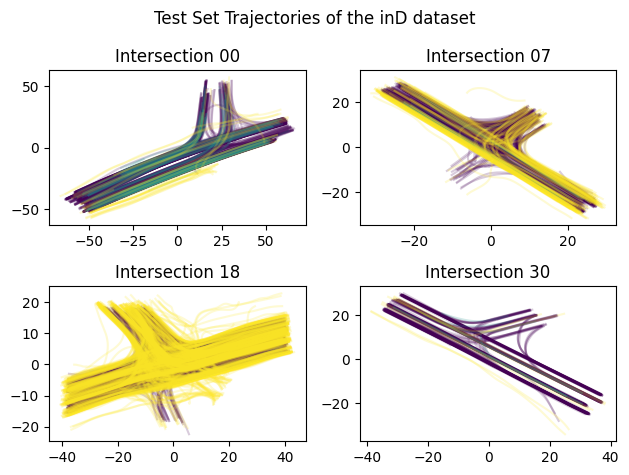

In [286]:
fig, axes = plt.subplots(2, 2)

for i, env_index in enumerate(index_shortlist):

    agent_type_list = [['car'], ['truck_bus'], ['bicycle']]
    split = splits[env_index][2]
    disambiguition = [split[split["class"].isin(agent_types)] for agent_types in agent_type_list]

    for j, trackset in enumerate(disambiguition):
        ids = trackset["trackId"].unique()

        for trackId in ids:
            track = trackset[trackset["trackId"] == trackId]
            axes[i // 2][i % 2].plot(track["xCenter"], track["yCenter"], 
                            alpha = 0.2, color = matplotlib.colormaps["viridis"](j / 2))
            axes[i // 2][i % 2].title.set_text(f"Intersection {env_index}")
    
fig.suptitle("Test Set Trajectories of the inD dataset")
fig.tight_layout()
fig.savefig(output_folder / "figures" / "experiments" / "ind_demo.pdf")

## Experiments

In [73]:
def experiment1(
    vehicle_df: pd.DataFrame,
    width, height,
    seed_value: int = 2024,
    constitutional_trust: float = 0.8,
    interpolator: Any | None = None,
    N: int = 2500,
    dt: float = 1/25,
    sensor_std_error = 1,
    process_noise = array([30, 20]),
):
    def create_initial_particles(N: int) -> ndarray:
        return np.stack(
            [
                uniform(loc=-width / 2, scale=width).rvs(N),  # x position (east)
                uniform(loc=-height / 2, scale=height).rvs(N),  # y position (north)
                uniform(loc=0, scale=2 * pi).rvs(N),  # heading
                norm(loc=40, scale=10).rvs(N),  # speed
            ]
        ).T
    
    def predict(particles, dt, process_noise):
        """move according to control input u (heading change, velocity)
        with noise Q (std heading change, std velocity)`"""

        scaled_noise = process_noise * dt
        
        particles = particles.copy()
        N = len(particles)

        # We first add noise to the heading
        particles[:, 2] += deg2rad(
            scaled_noise[0] * standard_normal(N)  # we can turn 90 degrees per second in each direction (95% interval) # but this is per time step? = 1/25th sec
        )
        particles[:, 2] %= 2 * pi

        # Add noise to the speed
        particles[:, 3] += scaled_noise[1]  * standard_normal(N) # pm 40 kmh 

        # Compute the actual distance we travel
        distance = particles[:, 3] * dt / 3.6 # to scale to m/s
        particles[:, 0] += np.cos(particles[:, 2]) * distance
        particles[:, 1] += np.sin(particles[:, 2]) * distance

        return particles
    

    def update(
        particles,
        weights,
        z,
        R,
        dt,
        constitutional_trust: float = constitutional_trust,
    ):
        weights = weights.copy()

        positions = particles[:, :2]
        distance = np.linalg.norm(positions - z, axis=1)

        # Evaluate an RBF kernel
        if dt > 0.01:
            weights *= norm.pdf(distance, 0, R) # remove dt

        if constitutional_trust > 0:
            this_interpolator = interpolator
            constitution = this_interpolator(particles)[:, 0]
            weight_change = constitutional_trust * constitution + (1 - constitutional_trust)
            # Disallow going to placed where the constitution is not even defined
            weight_change[~np.isfinite(constitution)] = 0
            weights *= weight_change

        weights += 1.0e-300  # avoid round-off to zero
        weights /= sum(weights)  # normalize

        return weights
    

    def estimate(particles, weights):
        """returns mean and variance of the weighted particles"""

        mean = np.average(particles, weights=weights, axis=0)
        var = np.average((particles - mean) ** 2, weights=weights, axis=0)
        return mean, var

    def neff(weights):
        return 1.0 / np.sum(np.square(weights))

    def resample_from_index(particles, weights, indexes):
        particles[:] = particles[indexes]
        weights.resize(len(particles))
        weights.fill(1.0 / len(weights))

    def run_pf1(
        N: int,
        data: np.ndarray,
        sensor_std_err,
        process_noise,
        do_plot=False,
        plot_particles=True,
        plot_every=3,
        dt=dt,
    ):
        if do_plot:
            plt.figure()

        # Create particles uniformly over the entire space
        particles = create_initial_particles(N)

        # However, for the location we can do a bit better by assuming that the current
        # observation is approximately correct
        particles[:, 0] = norm(loc=data[0, 0], scale=10).rvs(N)
        particles[:, 1] = norm(loc=data[0, 1], scale=10).rvs(N)

        # create weights
        weights = np.ones(N) / N

        if do_plot and plot_particles:
            alpha = 0.20
            if N > 5000:
                alpha *= np.sqrt(5000) / np.sqrt(N)
            plt.scatter(particles[:, 0], particles[:, 1], alpha=alpha, color="g")
            plt.show()

        weights_trace = []
        particle_trace = []
        xs = []
        for i, obs in enumerate(data):
            dt = obs[4]
            # move
            particles = predict(particles, dt=dt, process_noise=process_noise)

            # incorporate measurements
            weights = update(particles, weights, z=obs[:2], R=sensor_std_err, dt=dt)

            # resample if too few effective particles
            if neff(weights) < N / 2:
                # print("resample")
                indexes = stratified_resample(weights)
                resample_from_index(particles, weights, indexes)
                assert np.allclose(weights, 1 / N)
            else:
                # print("don't resample")
                pass

            mu, var = estimate(particles, weights)
            xs.append(mu)

            weights_trace.append(weights.copy())
            particle_trace.append(particles.copy())

            if do_plot and i % plot_every == 0:
                if plot_particles:
                    # top 10 percent of weights
                    percentile = 80
                    top_10_weight_val = np.percentile(weights, percentile)
                    print(top_10_weight_val, weights.max())
                    boosted_heaviest = np.where(weights >= top_10_weight_val, weights, 0)

                    plt.scatter(particles[:, 0], particles[:, 1], alpha= 1 * boosted_heaviest, color="g")
                # draw a cricle perimeter at 1 std
                plt.gca().add_artist(
                    plt.Circle((mu[0], mu[1]), radius=sensor_std_err, fill=False)
                )
                p1 = plt.scatter(obs[0], obs[1], marker="x", color="r")
                p2 = plt.scatter(mu[0], mu[1], marker="s", color="b")
                plt.xlim(-width / 2, width / 2)
                plt.ylim(-height / 2, height / 2)
                plt.show()

        xs = np.array(xs)
        if do_plot:
            plt.legend([p1, p2], ["Actual", "PF"], loc=4, numpoints=1)
            plt.show()

        pos_error = np.linalg.norm(xs[:, :2] - data[:, :2], axis=1)
        all_error = np.linalg.norm(xs[:, :] - data[:, :4], axis=1)

        if do_plot:
            plt.show()

        return {
            "particles": array(particle_trace),
            "weights": array(weights_trace),
            "estimates": xs,
            "pos_error": pos_error,
            "pos_error_mean": pos_error.mean(),
            "all_error": all_error,
            "all_error_mean": all_error.mean(),
            "truth": data,
        }


    ground_truth = stack(
        (
            vehicle_df["xCenter"],
            vehicle_df["yCenter"],
            deg2rad(vehicle_df["heading"]),
            vehicle_df["speed"],
            np.repeat(dt, len(vehicle_df))
        )
    ).T

    seed(seed_value)
    return run_pf1(
        N=N,
        data=ground_truth,
        sensor_std_err=sensor_std_error,
        process_noise=process_noise,
        do_plot=False,
        plot_every=6,
        dt=dt,
    )

dt = 1 / 25
take_every = 37
df = splits["00"][1]
trackId = df["trackId"].unique()[11]

env_index = "00"
support = CartesianDeltaCollection.load(promis_path / "landscape-00-1.5s--constitution.pkl")

compare = [experiment1(
    df[df["trackId"] == trackId][::take_every],
    width = dimensions_per_index[env_index][0],
    height = dimensions_per_index[env_index][1],
    seed_value=2025,
    constitutional_trust=trust_ratio,
    interpolator=support.get_interpolator(),
    dt=dt * take_every,
    process_noise=array([20, 30]),
    sensor_std_error=1,
    N=2500
) for trust_ratio in [0, 0.5, 1]]


res_specific = compare[1]


[0.22838108 0.48261672 0.30531405 0.20972867 0.16431612 0.1935191
 0.19742884 0.09660306 0.22517492 0.21869549 0.2710326  0.23627597]
[0.25694265 0.34534672 0.54070126 0.18587999 0.03902154 0.11967167
 0.31674859 0.21905184 0.28887388 0.34365325 0.04700146 0.11814172]
[0.27873704 1.26474755 0.0649081  0.14397742 0.04952524 0.20345565
 0.2378543  0.19149409 0.25920919 0.64967826 1.47827148 0.5502832 ]


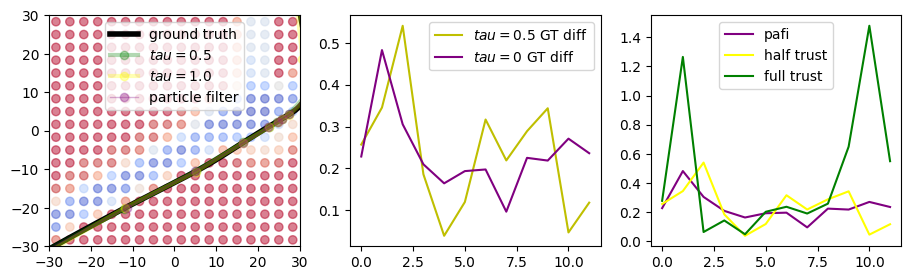

In [74]:
fig, axes = plt.subplots(1,3, figsize=(11,3))
axes[0].set_xlim(-30, 30)
axes[0].set_ylim(-30, 30)

plot = support.scatter(bearing = 270, speed = 40, plot_basemap=False, alpha=0.5, cmap = "coolwarm_r", ax = axes[0])
track = df[df["trackId"] == trackId]
axes[0].plot(track["xCenter"][20:], track["yCenter"][20:], linewidth=4, color="black", label="ground truth")

estimates1 = compare[1]["estimates"]
axes[0].plot(estimates1[:, 0], estimates1[:, 1], "o-", linewidth=3, alpha=0.3, color="green", label="$tau=0.5$")
estimates2 = compare[2]["estimates"]
axes[0].plot(estimates2[:, 0], estimates2[:, 1], "o-", linewidth=3, alpha=0.3, color="yellow", label="$tau=1.0$")
pafi = compare[0]["estimates"]
axes[0].plot(pafi[:, 0], pafi[:, 1], "o-", linewidth=1, alpha=0.3, color="purple", label="particle filter")

x = np.arange(len(pafi))
gt = df[df["trackId"] == trackId][::take_every][["xCenter", "yCenter"]]

d1 = np.linalg.norm(gt - estimates1[:, :2], axis=1)
d2 = np.linalg.norm(gt - pafi[:, :2], axis=1)
axes[1].plot(x, d1, c="y", label="$tau=0.5$ GT diff")
axes[1].plot(x, d2, c="purple", label="$tau=0$ GT diff")

for i, (label, color) in enumerate(zip(["pafi", "half trust", "full trust"], ["purple", "yellow", "green"])):
    data = compare[i]["pos_error"]
    print(data)
    axes[2].plot(x, data, c=color, label=label)  

axes[0].legend()
axes[1].legend()
axes[2].legend()
pass

In [75]:
estimates = res_specific["estimates"][:, :2]
truth = res_specific["truth"]
len(estimates), len(truth)
for i in range(3):
    print (compare[i]["pos_error_mean"])


0.23575721867104896
0.23508621508305294
0.44767846178323745


### Experiment
Now that a single example runs through, it is time to evaluate the performance of a particle filter both with our constitution and without it. What split to use?



Text(0.5, 0, 'number of agents')

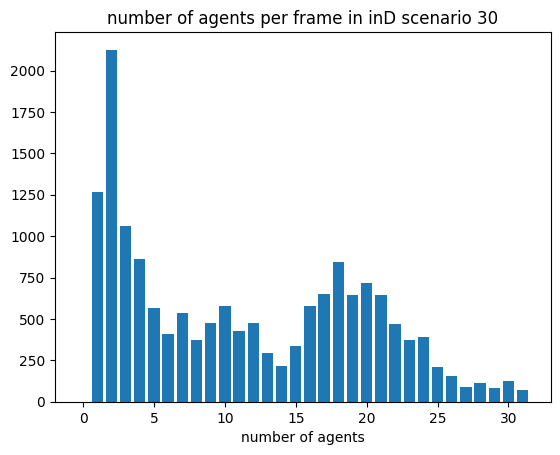

In [76]:
by_frames = splits["00"][2].groupby("frame").count()
max_agents = by_frames["trackId"].max() + 1
agents_per_frame = [len(by_frames[by_frames["trackId"] == i]) for i in range(max_agents)]
ax = plt.subplot()
ax.bar(np.arange(max_agents), agents_per_frame)
ax.set_title(f"number of agents per frame in inD scenario {inD_index}")
ax.set_xlabel("number of agents")

In [77]:
def evaluate_trust_ratio(data: pd.DataFrame, N: int, sample_every: int, env_index, interpolator, sensor_error = 1):
    trust_partitions = 10
    dt = 1/25
    return stack([
            np.array(
                [itemgetter("pos_error_mean", "all_error_mean")(experiment1(
                    data[data["trackId"] == trackId][::sample_every],
                    width = dimensions_per_index[env_index][0],
                    height = dimensions_per_index[env_index][1],
                    seed_value=2026,
                    constitutional_trust=trust,
                    interpolator=interpolator,
                    N=N,
                    dt=sample_every*dt,
                    process_noise=array([20, 10]),
                    sensor_std_error=sensor_error,
                )) for trust in np.arange(trust_partitions + 1) / trust_partitions]
            ) for trackId in data["trackId"].unique()[::]]
        )

In [78]:
from multiprocessing import Pool
from functools import partial

In [ ]:
process_noise_h = np.arange(10, 101, 10)
process_noise_v = np.arange(10, 101, 10)

sample_rate = 75
dt = 3
trust = 0
sensor_std_error = 1
n = 3000


def worker(trackId, h, v, interpolator, validation_set):
    return itemgetter("pos_error_mean", "all_error_mean")(experiment1(
            validation_set[validation_set["trackId"] == trackId][::sample_rate],
            width = dimensions_per_index[env_index][0],
            height = dimensions_per_index[env_index][1],
            seed_value=2026,
            constitutional_trust=trust,
            interpolator=interpolator,
            N=n,
            process_noise=array([h, v]), # first heading noise, then velocity
            sensor_std_error = sensor_std_error,
            dt=dt
    ))

def process_noise_grid_search(validation_set, env_index, support):

    grid_search_results = []
    interpolator = support.get_interpolator()
    with Pool(8) as p:
        for h, v in tqdm(product(process_noise_h, process_noise_v)):
            p_worker = partial(worker, h=h, v=v, interpolator=interpolator, validation_set=validation_set)
            grid_search_results.append(
                [h, v, n, sample_rate, sensor_std_error, trust, *np.mean(    
                    np.array(
                        p.map(
                            p_worker,
                            validation_set["trackId"].unique()[::10],
                        )      
                    ),
                axis=0)
            ])

    grid_search_results = pd.DataFrame(array(grid_search_results), 
        columns=["h_noise", "v_noise", "n", "rate", "std_err", "trust", "pos_error_mean", "all_error_mean"])
    grid_search_results.to_csv(output_folder / f"gridsearch_res_{env_index}--{logic_name}.csv")

for i, (_, val_set, _) in splits.items():
    support = CartesianDeltaCollection.load(promis_path / f"landscape-{i}-{dt}s--{logic_name}.pkl")
    process_noise_grid_search(val_set, i, support)


In [ ]:
process_noise_parameters = {}
for env_index in index_shortlist:
    gs_data = pd.read_csv(output_folder / f"gridsearch_res_{env_index}--{logic_name}.csv")
    params = gs_data[gs_data["pos_error_mean"] == gs_data["pos_error_mean"].min()][["h_noise", "v_noise"]]
    process_noise_parameters[env_index] = params.iloc[0].to_numpy()

process_noise_parameters

In [29]:
def plot_ratios(n, data, env_index, logic_name):

    # print(f"N = {n}")
    # print(np.histogram(data[:, :, 0].argmin(axis=1), np.arange(data.shape[1] + 1) - 0.5))
    # print(data[:, :, 0].mean(axis = 0))
    
    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar(
        np.arange(data.shape[1]) / (data.shape[1]-1), 
        np.histogram(data[:, :, 0].argmin(axis=1), np.arange(data.shape[1] + 1) - 0.5)[0], 
        width=0.1,
        tick_label = np.arange(data.shape[1]) / (data.shape[1]-1),
    )
    ax.set_title(f"Optimal Trust Level for Different N on Intersection {env_index}")

    plt.savefig(output_folder / "figures" / f"optimal_trust_hist-{env_index}--{logic_name}.svg", format="svg")
    
    fig, ax = plt.subplots(figsize=(6, 4))
    index_min = pd.DataFrame({
        "index": data[:, :, 0].argmin(axis=1) / (data.shape[1] - 1), 
        "relative error": data[:, :, 0].min(axis=1) / data[:, 0, 0],
    })    
    sns.lineplot(data=index_min, x="index", y="relative error", ax=ax)
    ax.set_title(f"Mean Improvement for Optimal Trust Level on Intersection {env_index}")
    ax.set_xlabel("optimal $tau$")

    plt.savefig(output_folder / "figures" / f"optimal_trust_error_rel-{env_index}--{logic_name}.svg", format="svg")

    fig, ax = plt.subplots(figsize=(6, 4))
    index_min = pd.DataFrame({
        "index": data[:, :, 0].argmin(axis=1) / (data.shape[1] - 1), 
        "absolute error": data[:, :, 0].min(axis=1),
    })    
    sns.lineplot(data=index_min, x="index", y="absolute error", ax=ax)
    ax.set_title(f"Mean Improvement for Optimal Trust Level on Intersection {env_index}")
    ax.set_xlabel("optimal $tau$")

    plt.savefig(output_folder / "figures" / f"optimal_trust_error_abs-{env_index}--{logic_name}.svg", format="svg")



In [ ]:
logic_name = "constitution"
for env_index, group in [("00", group00), ("07", group07), ("18", group18), ("30", group30)]:
    t_set = splits[env_index][2]
    n = 3000
    car_data = t_set[t_set["class"].isin(["car", "truck_bus"])]
    support = CartesianDeltaCollection.load(promis_path / f"landscape-{env_index}-3s--{logic_name}.pkl")

    for_n = evaluate_trust_ratio(car_data, n, 75, env_index, support.get_interpolator())
    
    plot_ratios(n, for_n, env_index, logic_name)

In [ ]:
def analyze_divergence(data: pd.DataFrame, group: list[str], env_index: str, N: int, sample_every: int, support: str):
    ax = plt.subplot()
    interpolator = support.get_interpolator()
    support.scatter(bearing = 320, speed = 30, ax=ax, alpha=0.5, cmap="coolwarm_r")
    trust = 0.8
    w, h = dimensions_per_index[env_index]

    for g_id in group:
        car_data = data[data["group"] == g_id]
        for trackId in car_data["trackId"].unique():
            res = experiment1(
                car_data[car_data["trackId"] == trackId][::sample_every],
                seed_value=2026,
                constitutional_trust=trust,
                interpolator=interpolator,
                N=N,
                dt=sample_every*dt,
                width=w, 
                height=h,
            )
            error = res["pos_error"]
            pred = res["estimates"]
            pos = car_data[car_data["trackId"] == trackId][::sample_every][["xCenter", "yCenter"]].to_numpy()
            hi_error = np.quantile(error, 0.95)
            hi_error_pos = pos[error >= hi_error, :]
            hi_error_pred = pred[error >= hi_error, :]
            ax.scatter(hi_error_pred[:, 0], hi_error_pred[:, 1], alpha=0.9, c="red", s=4)
            for i in range(len(hi_error_pos)):
                ax.plot(
                    [hi_error_pos[i, 0], hi_error_pred[i, 0]],
                    [hi_error_pos[i, 1], hi_error_pred[i, 1]],
                    c="black",
                )

    ax.set_xlim(-20, 20)
    ax.set_ylim(-20, 20)
    return ax


In [79]:
def error_data_for_logics(group, env_index, interpolators, n = 3000):
    _, _, t_set = val_test_split(group)
    car_data = t_set
    data_list = {}
    for logic_name, interpolator in interpolators.items():
        data = evaluate_trust_ratio(car_data, n, 75, group, env_index, interpolator)
        data_list[logic_name] = data

    return data_list

In [83]:
errors_per_landscape_per_agent = {}
for env_index in index_shortlist:
    error_data = {}
    car_data = splits[env_index][2]
    for agent_type in ["car", "truck_bus", "bicycle"]:
        error_data[agent_type] = evaluate_trust_ratio(
            car_data[car_data["class"] == agent_type],
            N=3000,
            sample_every=75,
            env_index=env_index,
            interpolator=DeltaGrid.load(promis_path / f"landscape-{env_index}-3s--trusted_{agent_type}2.pkl").get_interpolator(),
            sensor_error=1
        )
    errors_per_landscape_per_agent[env_index] = error_data

In [201]:
def compare_opt_trust(env_index, data_list: dict, plot_pafi = True, comp_name ="", axes=None, color_dict={}):
    if axes == None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        ax = axes[0]

    width = 0.2
    trust_num = 11
    x = np.arange(trust_num)
    for i, (logic_name, data) in enumerate(data_list.items()):
        offset = i * width
        x_ = x + offset
        ax.bar(
            x_, 
            np.histogram(data[:, :, 0].argmin(axis=1), np.arange(data.shape[1] + 1) - 0.5)[0], 
            width=width,
            label=logic_name,
            color=color_dict[logic_name],
        )

    ax.set_title(f"Optimal Trust Level on Intersection {env_index} for Different Logics")
    ax.set_xticks(x+width, x / (trust_num - 1))
    ax.legend(loc='upper right')
    plt.savefig(output_folder / "figures" / f"tau_comp_hist-{env_index}-{comp_name}.svg", format="svg")
        

    if axes == None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        ax = axes[1]
    
    for logic_name, data in data_list.items():
        index_min = pd.DataFrame({
            "index": data[:, :, 0].argmin(axis=1) / (data.shape[1] - 1), 
            "relative error": data[:, :, 0].min(axis=1) / data[:, 0, 0],
            },
        )    
        sns.lineplot(data=index_min, x="index", y="relative error", ax=ax, label=logic_name,
            color=color_dict[logic_name],)

    ax.set_title(f"Mean Improvement for Optimal Trust Level on Intersection {env_index}")
    ax.set_xlabel("optimal $tau$")
    ax.set_ylabel("mean relative error")
    ax.legend(loc='upper right')

    plt.savefig(output_folder / "figures" / f"tau_rel_error_comp-{env_index}-{comp_name}.svg", format="svg")

    if axes == None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        ax = axes[1]    

    for logic_name, data in data_list.items():
        index_min = pd.DataFrame({
            "index": data[:, :, 0].argmin(axis=1) / (data.shape[1] - 1), 
            "absolute error": data[:, :, 0].min(axis=1),
            },
        )    
        sns.lineplot(data=index_min, x="index", y="absolute error", ax=ax, label=logic_name,
            color=color_dict[logic_name],)
        
    ax.set_title(f"Mean Error for Optimal Trust Level on Intersection {env_index}")
    ax.set_xlabel("optimal $tau$")
    ax.set_ylabel("mean error")
    ax.legend(loc='upper right')
    plt.savefig(output_folder / "figures" / f"tau_abs_error_comp-{env_index}-{comp_name}.svg", format="svg")

    if axes == None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        ax = axes[2]    
    
    for logic_name, data in data_list.items():
        index_min = pd.DataFrame({
            "index": np.arange(0, 1.1, 0.1,), 
            "absolute error": data[:, :, 0].mean(axis=0),
            },
        )    
        sns.lineplot(data=index_min, x="index", y="absolute error", ax=ax, label=logic_name,
            color=color_dict[logic_name],)
        
    ax.set_title(f"Mean Error any Trust Level on Intersection {env_index}")
    ax.set_xlabel("optimal $tau$")
    ax.set_ylabel("mean error")
    ax.legend(loc='upper right')
    plt.savefig(output_folder / "figures" / f"tau_abs_error-{env_index}.svg", format="svg")

    if axes == None:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.set_title(f"Mean Error for Best Prediction on Intersection {env_index}")
        ax.set_xlabel("logic")
    else:
        ax = axes[3]

    for i, (logic_name, data) in enumerate(data_list.items()):
        ax.violinplot(data[:, :, 0].min(axis=1), [2*(i + 1)],
            showmeans=True, showextrema=True, 
            # color=color_dict[logic_name],
        )
        ax.text(2*(i+1), 0.05, str(data[:, :, 0].min(axis=1).mean())[:5]    )

    start = 1
    if plot_pafi:
        # for a particle filter, predictions should be the same for all logics
        ax.violinplot(data[:, 0, 0], [0],
            showmeans=True, showextrema=True,
        )
        ax.text(0, 0.05, str(data[:, 0, 0].mean())[:5])
        start = 0
        
   
    ax.set_xticks([2*i for i in range(len(data_list) + 1)][start:], ["particle filter", *data_list.keys()][start:])
    ax.set_ylabel("mean error")
    ax.legend(loc='upper right')

    plt.savefig(output_folder / "figures" / f"tau_mean_error_comp-{env_index}-{comp_name}.svg", format="svg")



/tmp/ipykernel_406506/3725617137.py:114: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


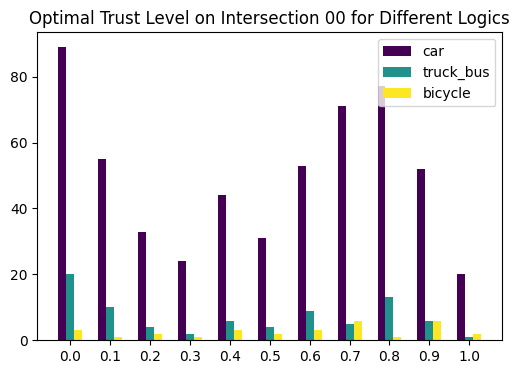

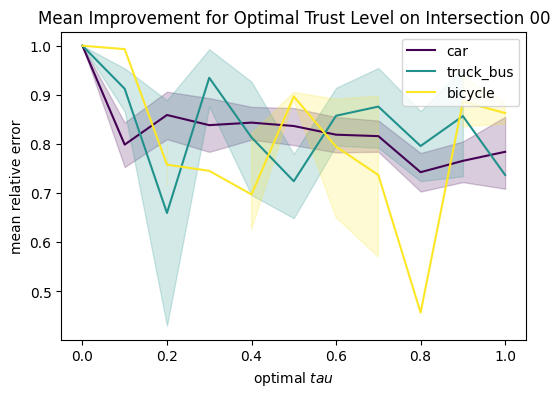

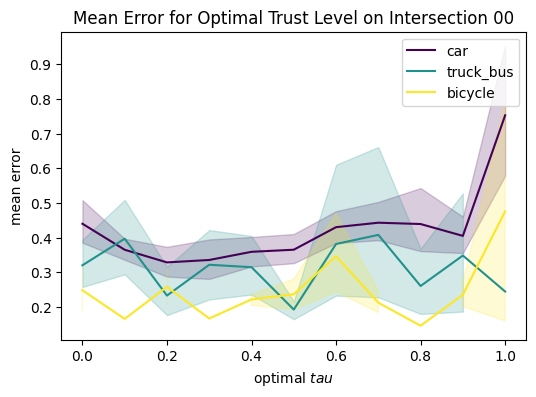

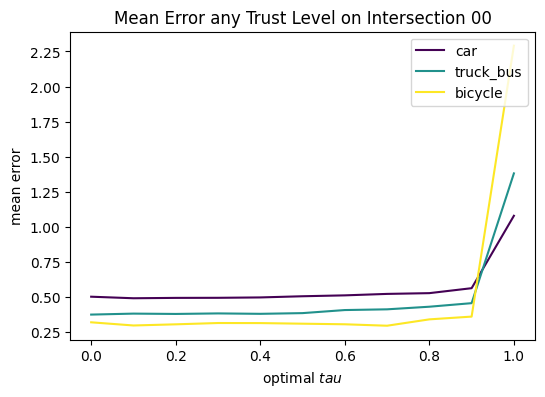

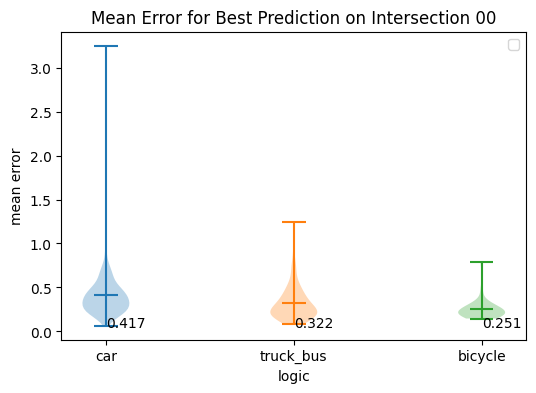

In [ ]:
env_index = "00"
color_dict = {
    agent_type: matplotlib.colormaps["viridis"](i/2) for i, agent_type in enumerate(["car", "truck_bus", "bicycle"]) 
}

plt.subplots(4, )
compare_opt_trust(env_index, errors_per_landscape_per_agent[env_index], plot_pafi=False, comp_name="3s-agents", color_dict=color_dict )

00 car [1.         0.97450338 0.97902475 0.98137707 0.98660502 0.99821834
 1.01453731 1.04047343 1.05316223 1.11991036 1.94763783]
00 truck_bus [1.         1.02038377 1.02346185 1.03401315 1.0167617  1.0349858
 1.0828002  1.09421054 1.14501188 1.24209402 3.19695434]
00 bicycle [1.         0.94707822 0.94820563 1.00232415 0.97830193 0.98696316
 0.962913   0.92027539 1.08015497 1.1283383  6.77626741]
07 car [1.         0.98708512 0.99480559 1.01664693 1.02679978 1.04561419
 1.07822631 1.10812702 1.19325967 1.31793077 1.79994702]
07 truck_bus [1.         0.97887394 0.98342829 1.02560729 1.01347199 1.07461556
 1.11040479 1.18044006 1.30908783 1.40309793 1.75501484]
07 bicycle [1.         0.98567056 0.98174307 1.00180876 1.02185838 1.05245391
 1.07080029 1.1120608  1.18055391 1.30863623 2.49174088]
18 car [1.         0.99107568 1.0017124  1.00866681 1.01403922 1.01684149
 1.02879248 1.06229817 1.12449101 1.26359396 2.79573107]
18 truck_bus [1.         0.90742222 1.01592942 1.0516865  1.0587

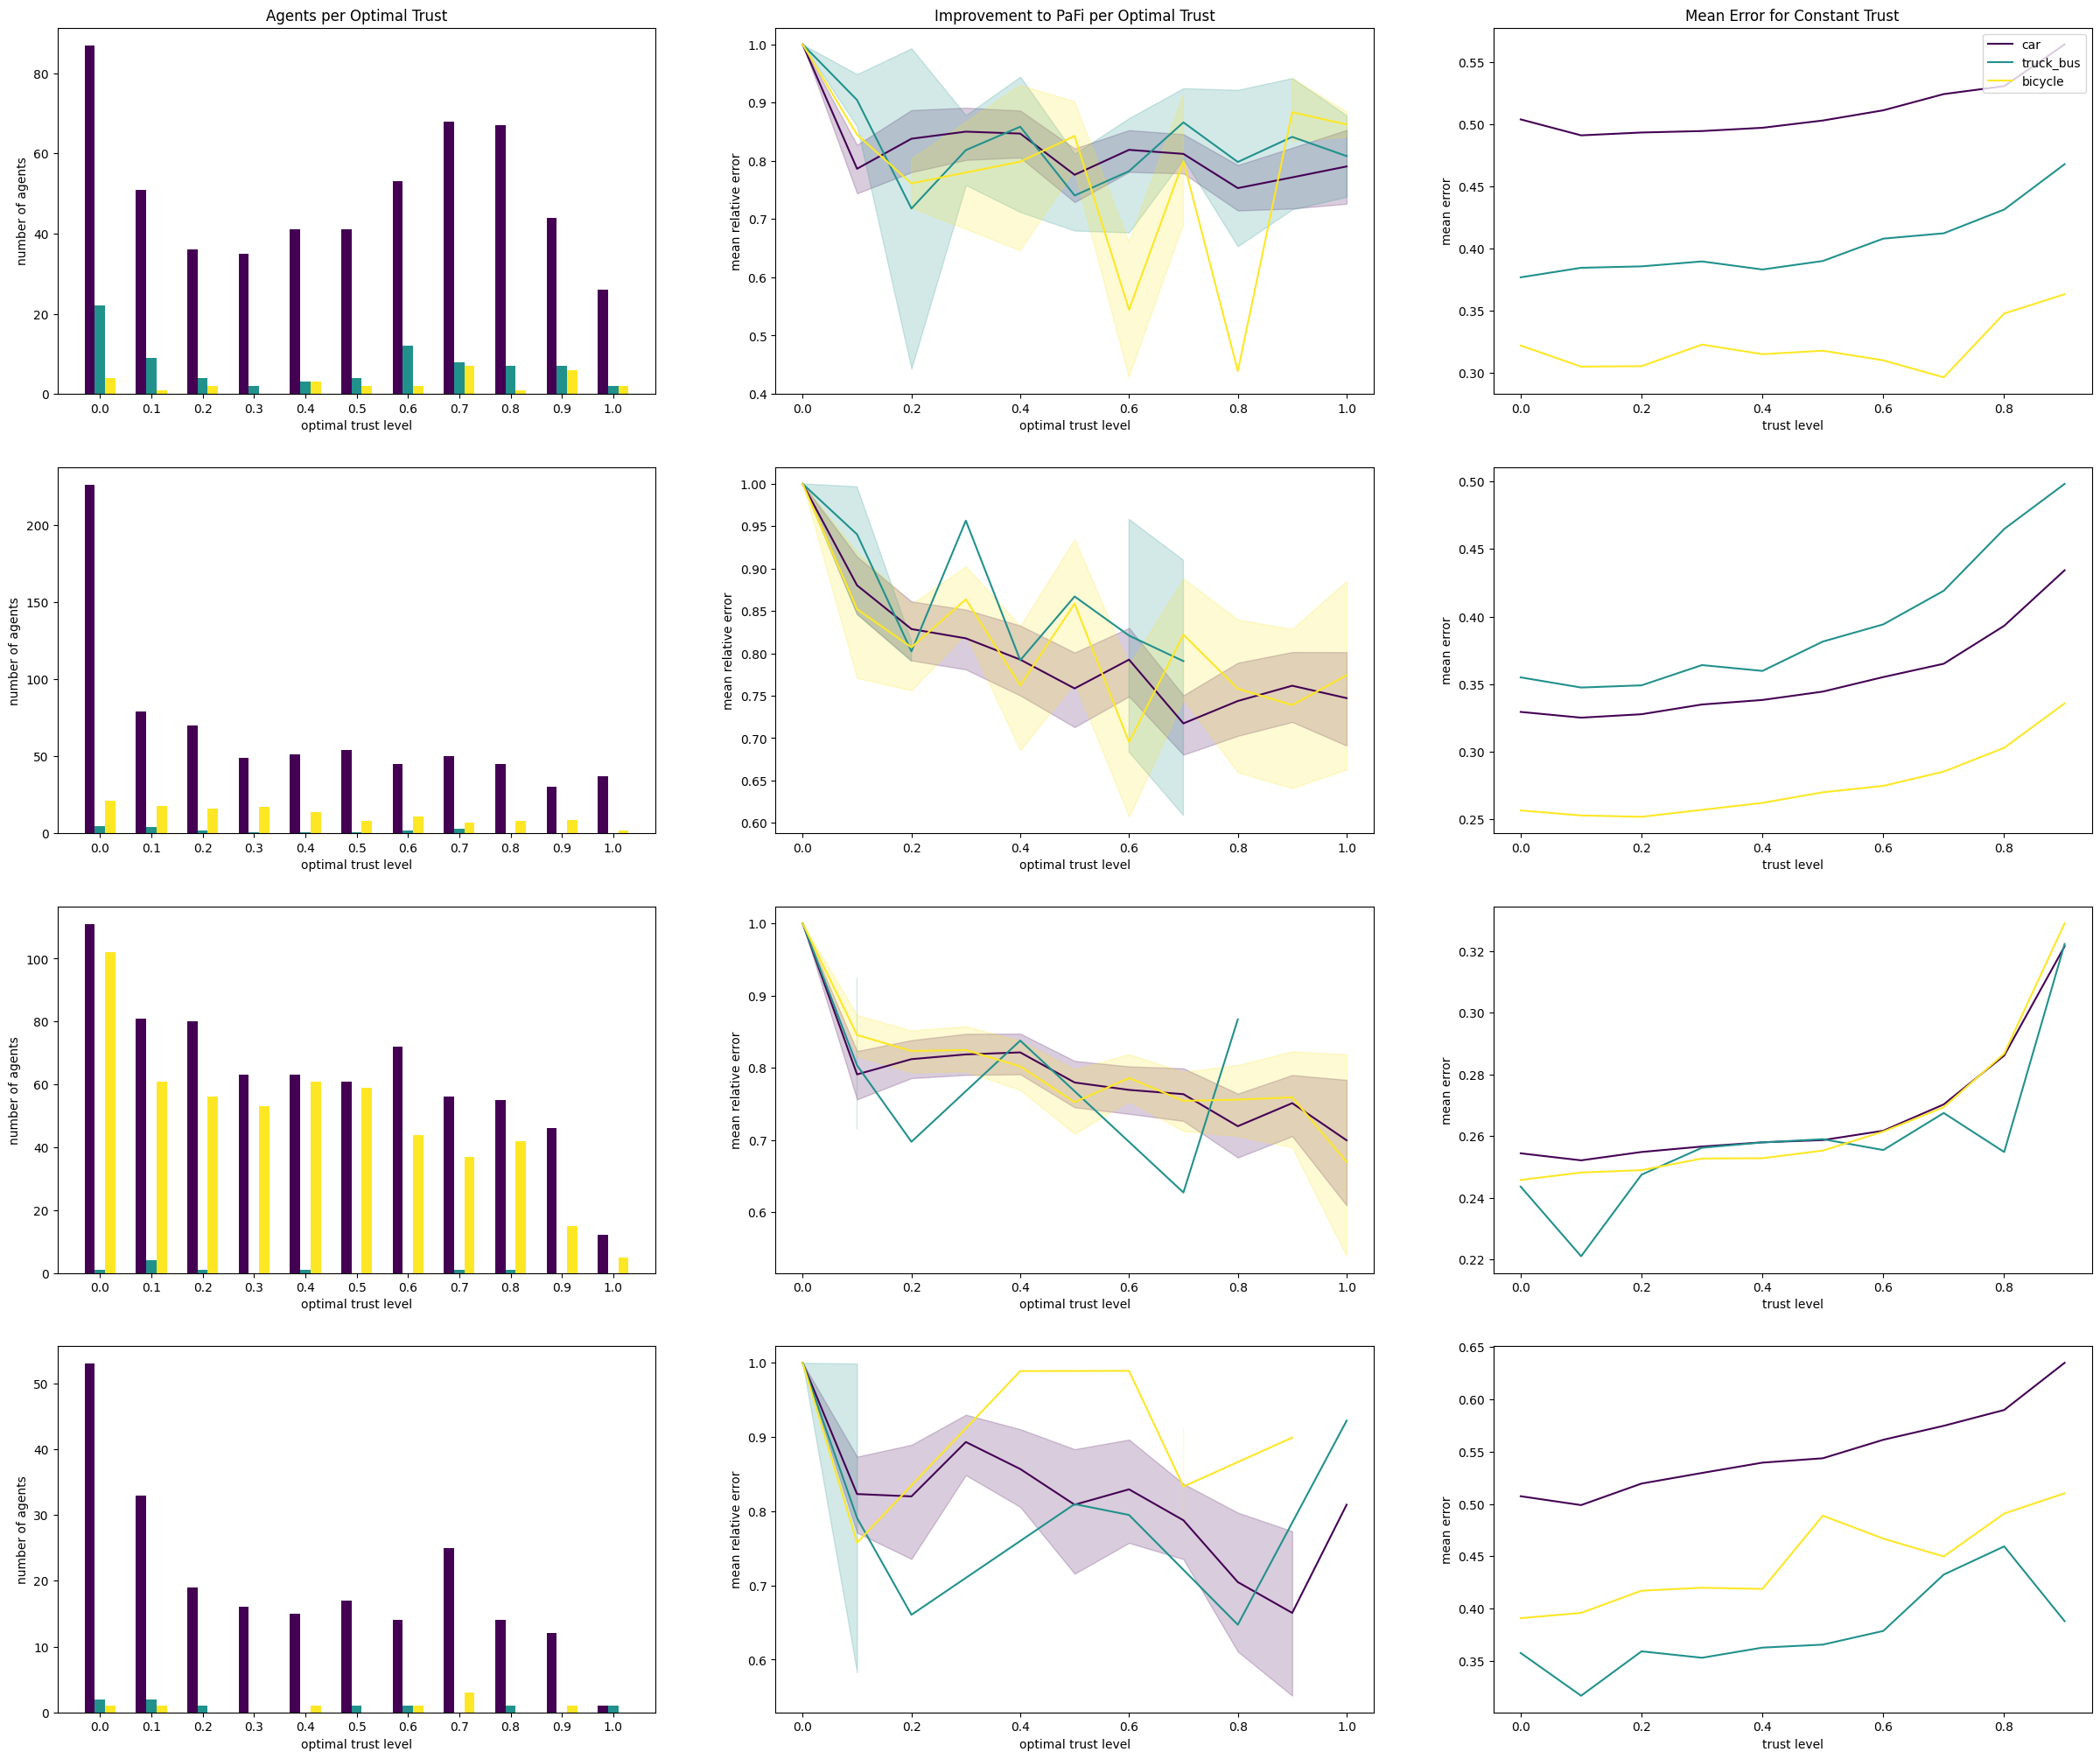

In [ ]:

color_dict = {
    agent_type: matplotlib.colormaps["viridis"](i/2) for i, agent_type in enumerate(["car", "truck_bus", "bicycle"]) 
}

fig, ax = plt.subplots(4, 3, figsize=(30, 25))

for ax_i, env_index in enumerate(index_shortlist):
    data_list =  errors_per_landscape_per_agent[env_index]
    ### histogram
    width = 0.2
    trust_num = 11
    x = np.arange(trust_num)

    hist_list = []
    for i, (logic_name, data) in enumerate(data_list.items()):
        offset = i * width
        x_ = x + offset
        hist_data_ = np.histogram(data[:, :, 0].argmin(axis=1), np.arange(data.shape[1] + 1) - 0.5)
        hist_list.append(hist_data_[0])
        
        ax[ax_i][0].bar(
            x_, 
            hist_data_[0], 
            width=width,
            label=logic_name,
            color=color_dict[logic_name],
        )

    ax[ax_i][0].set_ylabel("number of agents")
    ax[ax_i][0].set_xlabel("optimal trust level")
    # ax[ax_i][0].legend(loc='upper right')
    ax[ax_i][0].set_xticks(x+width, x / (trust_num - 1))

    

    ### error opt trust
    for logic_name, data in data_list.items():
        index_min = pd.DataFrame({
            "index": data[:, :, 0].argmin(axis=1) / (data.shape[1] - 1), 
            "relative error": data[:, :, 0].min(axis=1) / data[:, 0, 0],
            },
        )    
        sns.lineplot(data=index_min, x="index", y="relative error", ax=ax[ax_i][1], label=logic_name,
            color=color_dict[logic_name],)

    ax[ax_i][1].set_xlabel("optimal trust level")
    ax[ax_i][1].set_ylabel("mean relative error")
    ax[ax_i][1].get_legend().remove()

    
    for logic_name, data in data_list.items():
        index_min = pd.DataFrame({
            "index": np.arange(0, 1.1, 0.1,)[:-1], 
            "absolute error": data[:, :, 0].mean(axis=0)[:-1],
            },
        )    
        sns.lineplot(data=index_min, x="index", y="absolute error", ax=ax[ax_i][2], label=logic_name,
            color=color_dict[logic_name],)
        print(env_index, logic_name, data[:, :, 0].mean(axis=0) / data[:, :, 0].mean(axis=0)[0])
        
    ax[ax_i][2].set_xlabel("trust level")
    ax[ax_i][2].set_ylabel("mean error")
        
    


ax[0][0].title.set_text("Agents per Optimal Trust")
ax[0][1].title.set_text("Improvement to PaFi per Optimal Trust")
ax[0][2].title.set_text("Mean Error for Constant Trust")
ax[0][2].legend(loc='upper right')

for i in range(3):
    ax[i+1][2].get_legend().remove()

plt.savefig(output_folder / "figures" / "experiments" / "agent_landscape_trust.pdf")
plt.savefig(output_folder / "figures" / "experiments" / "agent_landscape_trust.svg")
    

In [204]:

color_dict = {
    agent_type: matplotlib.colormaps["viridis"](i/2) for i, agent_type in enumerate(["car", "truck_bus", "bicycle"]) 
}

/tmp/ipykernel_72874/1630559047.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0][1].legend(loc='upper right')
/tmp/ipykernel_72874/1630559047.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0][1].legend(loc='upper right')
/tmp/ipykernel_72874/1630559047.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0][1].legend(loc='upper right')


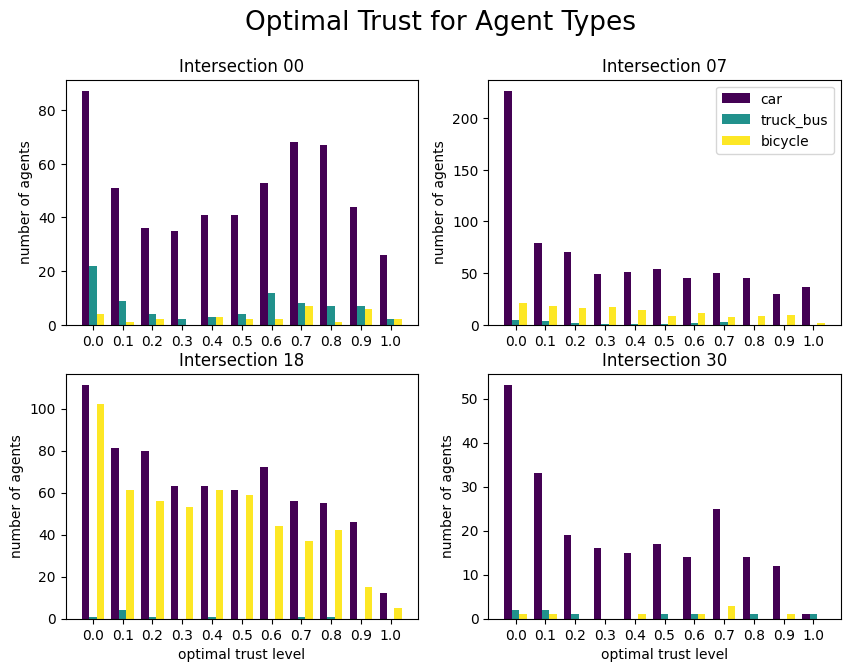

In [227]:

fig, ax = plt.subplots(2, 2, figsize=(10, 7))

for ax_i, env_index in enumerate(index_shortlist):
    data_list =  errors_per_landscape_per_agent[env_index]
    width = 0.25
    trust_num = 11
    x = np.arange(trust_num)

    hist_list = []
    for i, (logic_name, data) in enumerate(data_list.items()):
        this_ax = ax[ax_i // 2][ax_i % 2]
        offset = i * width
        x_ = x + offset
        hist_data_ = np.histogram(data[:, :, 0].argmin(axis=1), np.arange(data.shape[1] + 1) - 0.5)
        hist_list.append(hist_data_[0])
        
        this_ax.bar(
            x_, 
            hist_data_[0], 
            width=width,
            label=logic_name,
            color=color_dict[logic_name],
        )
        this_ax.title.set_text(f"Intersection {env_index}")
        this_ax.set_ylabel("number of agents")
        ax[1][ax_i % 2].set_xlabel("optimal trust level")
        ax[0][1].legend(loc='upper right')
        this_ax.set_xticks(x+width, x / (trust_num - 1))

fig.suptitle("Optimal Trust for Agent Types", fontsize = 19)
plt.savefig(output_folder / "figures" / "experiments" / "opt_trust_hist_full.pdf")
plt.savefig(output_folder / "figures" / "experiments" / "opt_trust_hist_full.svg")


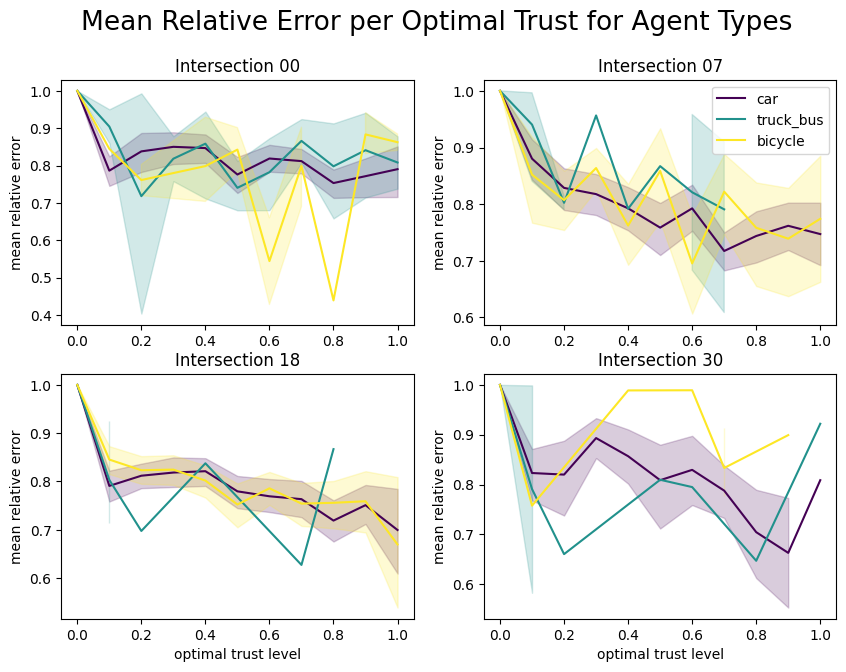

In [287]:

fig, ax = plt.subplots(2, 2, figsize=(10, 7))

for ax_i, env_index in enumerate(index_shortlist):
    data_list =  errors_per_landscape_per_agent[env_index]
    this_ax = ax[ax_i // 2][ax_i % 2]
    
    ### error opt trust
    for logic_name, data in data_list.items():
        index_min = pd.DataFrame({
            "index": data[:, :, 0].argmin(axis=1) / (data.shape[1] - 1), 
            "relative error": data[:, :, 0].min(axis=1) / data[:, 0, 0],
            },
        )    
        sns.lineplot(data=index_min, x="index", y="relative error", ax=this_ax, label=logic_name,
            color=color_dict[logic_name],)
        
    this_ax.get_legend().remove()
    this_ax.set_xlabel("")

    this_ax.title.set_text(f"Intersection {env_index}")
    this_ax.set_ylabel("mean relative error")
    ax[1][ax_i % 2].set_xlabel("optimal trust level")

    
ax[0][1].legend(loc='upper right')
fig.suptitle("Mean Relative Error per Optimal Trust for Agent Types", fontsize = 19)
plt.savefig(output_folder / "figures" / "experiments" / "opt_trust_rel_error_full.pdf")
plt.savefig(output_folder / "figures" / "experiments" / "opt_trust_rel_error_full.svg")

00 car [1.         0.97450338 0.97902475 0.98137707 0.98660502 0.99821834
 1.01453731 1.04047343 1.05316223 1.11991036 1.94763783]
00 truck_bus [1.         1.02038377 1.02346185 1.03401315 1.0167617  1.0349858
 1.0828002  1.09421054 1.14501188 1.24209402 3.19695434]
00 bicycle [1.         0.94707822 0.94820563 1.00232415 0.97830193 0.98696316
 0.962913   0.92027539 1.08015497 1.1283383  6.77626741]
07 car [1.         0.98708512 0.99480559 1.01664693 1.02679978 1.04561419
 1.07822631 1.10812702 1.19325967 1.31793077 1.79994702]
07 truck_bus [1.         0.97887394 0.98342829 1.02560729 1.01347199 1.07461556
 1.11040479 1.18044006 1.30908783 1.40309793 1.75501484]
07 bicycle [1.         0.98567056 0.98174307 1.00180876 1.02185838 1.05245391
 1.07080029 1.1120608  1.18055391 1.30863623 2.49174088]
18 car [1.         0.99107568 1.0017124  1.00866681 1.01403922 1.01684149
 1.02879248 1.06229817 1.12449101 1.26359396 2.79573107]
18 truck_bus [1.         0.90742222 1.01592942 1.0516865  1.0587

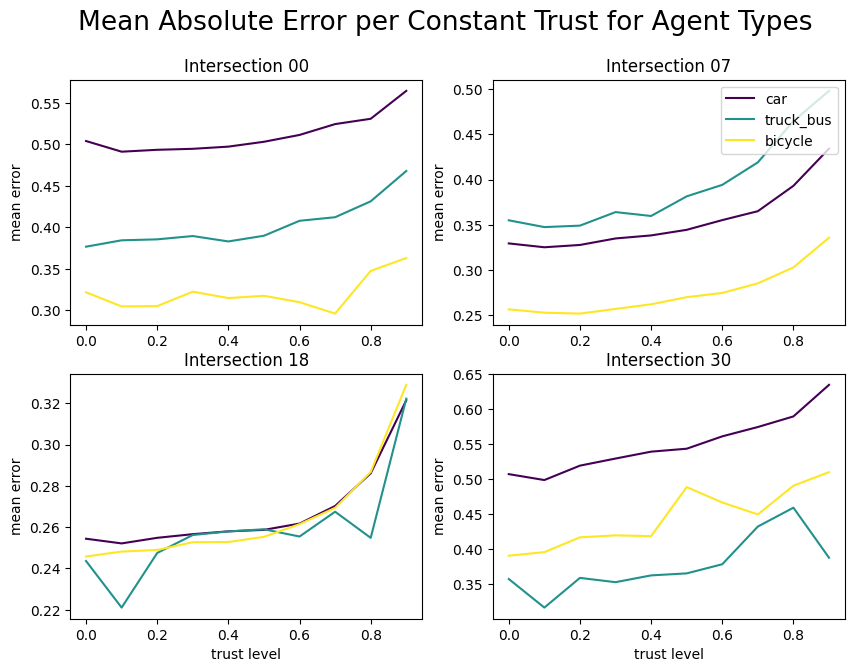

In [229]:

fig, ax = plt.subplots(2, 2, figsize=(10, 7))

for ax_i, env_index in enumerate(index_shortlist):
    data_list =  errors_per_landscape_per_agent[env_index]
    this_ax = ax[ax_i // 2][ax_i % 2]
    
    for logic_name, data in data_list.items():
        index_min = pd.DataFrame({
            "index": np.arange(0, 1.1, 0.1,)[:-1], 
            "absolute error": data[:, :, 0].mean(axis=0)[:-1],
            },
        )    
        sns.lineplot(data=index_min, x="index", y="absolute error", ax=this_ax, label=logic_name,
            color=color_dict[logic_name],)
        print(env_index, logic_name, data[:, :, 0].mean(axis=0) / data[:, :, 0].mean(axis=0)[0])
        
    this_ax.set_xlabel("")
    this_ax.get_legend().remove()
    this_ax.title.set_text(f"Intersection {env_index}")
    ax[ax_i // 2][ax_i % 2].set_ylabel("mean error")
    ax[1][ax_i % 2].set_xlabel("trust level")

ax[0][1].legend(loc='upper right')
fig.suptitle("Mean Absolute Error per Constant Trust for Agent Types", fontsize = 19)
plt.savefig(output_folder / "figures" / "experiments" / "mean_trust_abs_error_full.pdf")
plt.savefig(output_folder / "figures" / "experiments" / "mean_trust_abs_error_full.svg")

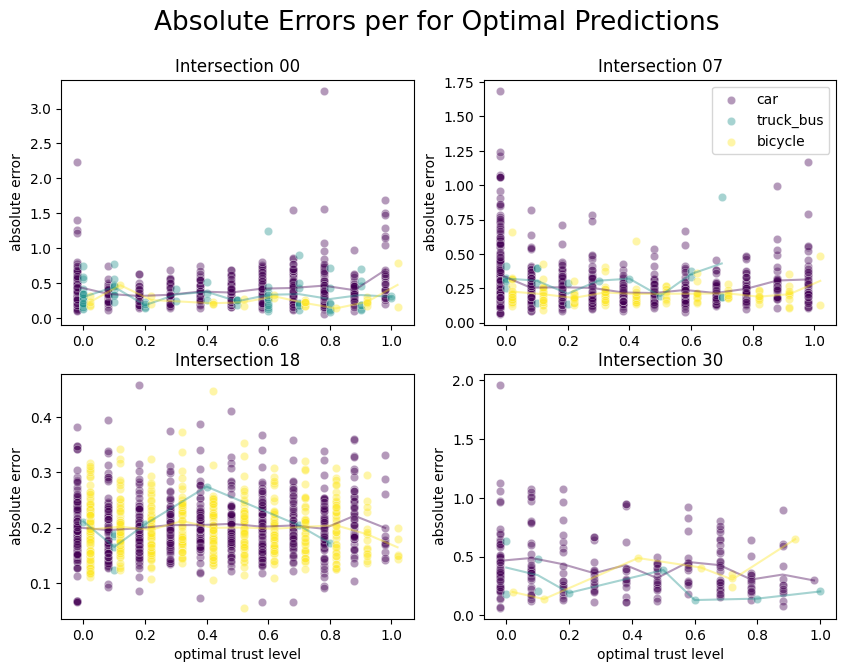

In [230]:
fig, ax = plt.subplots(2, 2, figsize=(10, 7))

for ax_i, env_index in enumerate(index_shortlist):
    data_list =  errors_per_landscape_per_agent[env_index]
    this_ax = ax[ax_i // 2][ax_i % 2]

    width = 0.02
    for i, (logic_name, data) in enumerate(data_list.items()):
        index_min = pd.DataFrame({
            "index": data[:, :, 0].argmin(axis=1) / (data.shape[1] - 1) - width + i*width , 
            "absolute error": data[:, :, 0].min(axis=1),
            },
        )    
        sns.scatterplot(data=index_min, x="index", y="absolute error", ax=this_ax, label=logic_name,
            color=color_dict[logic_name], alpha = 0.4)
        sns.lineplot(data=index_min, x="index", y="absolute error", ax=this_ax,
            color=color_dict[logic_name], alpha = 0.4, errorbar=None)
        
    this_ax.set_title(f"Intersection {env_index}")
    this_ax.set_xlabel("")
    this_ax.set_ylabel("absolute error")
    ax[1][ax_i % 2].set_xlabel("optimal trust level")

    
    this_ax.get_legend().remove()

ax[0][1].legend(loc='upper right')

fig.suptitle("Absolute Errors per for Optimal Predictions", fontsize = 19)
plt.savefig(output_folder / "figures" / "experiments" / "opt_trust_abs_error_full.pdf")
plt.savefig(output_folder / "figures" / "experiments" / "opt_trust_abs_error_full.svg")

### No road sides

In [121]:
errors_reduced = {}
for env_index in index_shortlist:
    error_data = {}
    car_data = splits[env_index][2]
    for agent_type in ["car"]:
        error_data[agent_type] = evaluate_trust_ratio(
            car_data[car_data["class"] == agent_type],
            N=3000,
            sample_every=75,
            env_index=env_index,
            interpolator=DeltaGrid.load(promis_path / f"landscape-{env_index}-3s--reduced_{agent_type}.pkl").get_interpolator(),
            sensor_error=1
        )
    errors_reduced[env_index] = error_data

00 car [1.         0.99940073 0.99979154 1.00163084 1.00170955 1.00129697
 1.00599847 1.00853141 1.01062197 1.01521256 1.02073606]
07 car [1.         1.00139549 1.00224971 1.00272024 1.00366902 1.00530983
 1.00713705 1.00967127 1.01161855 1.01593248 1.02242313]
18 car [1.         0.99955185 0.99919808 0.9987466  0.99856937 0.99848056
 0.99901957 0.99878    0.9990551  0.99959937 1.00017847]
30 car [1.         1.00110619 0.99975297 0.99822886 0.99850007 0.9971533
 0.99522255 0.99471539 0.9969847  0.99812156 1.00193168]


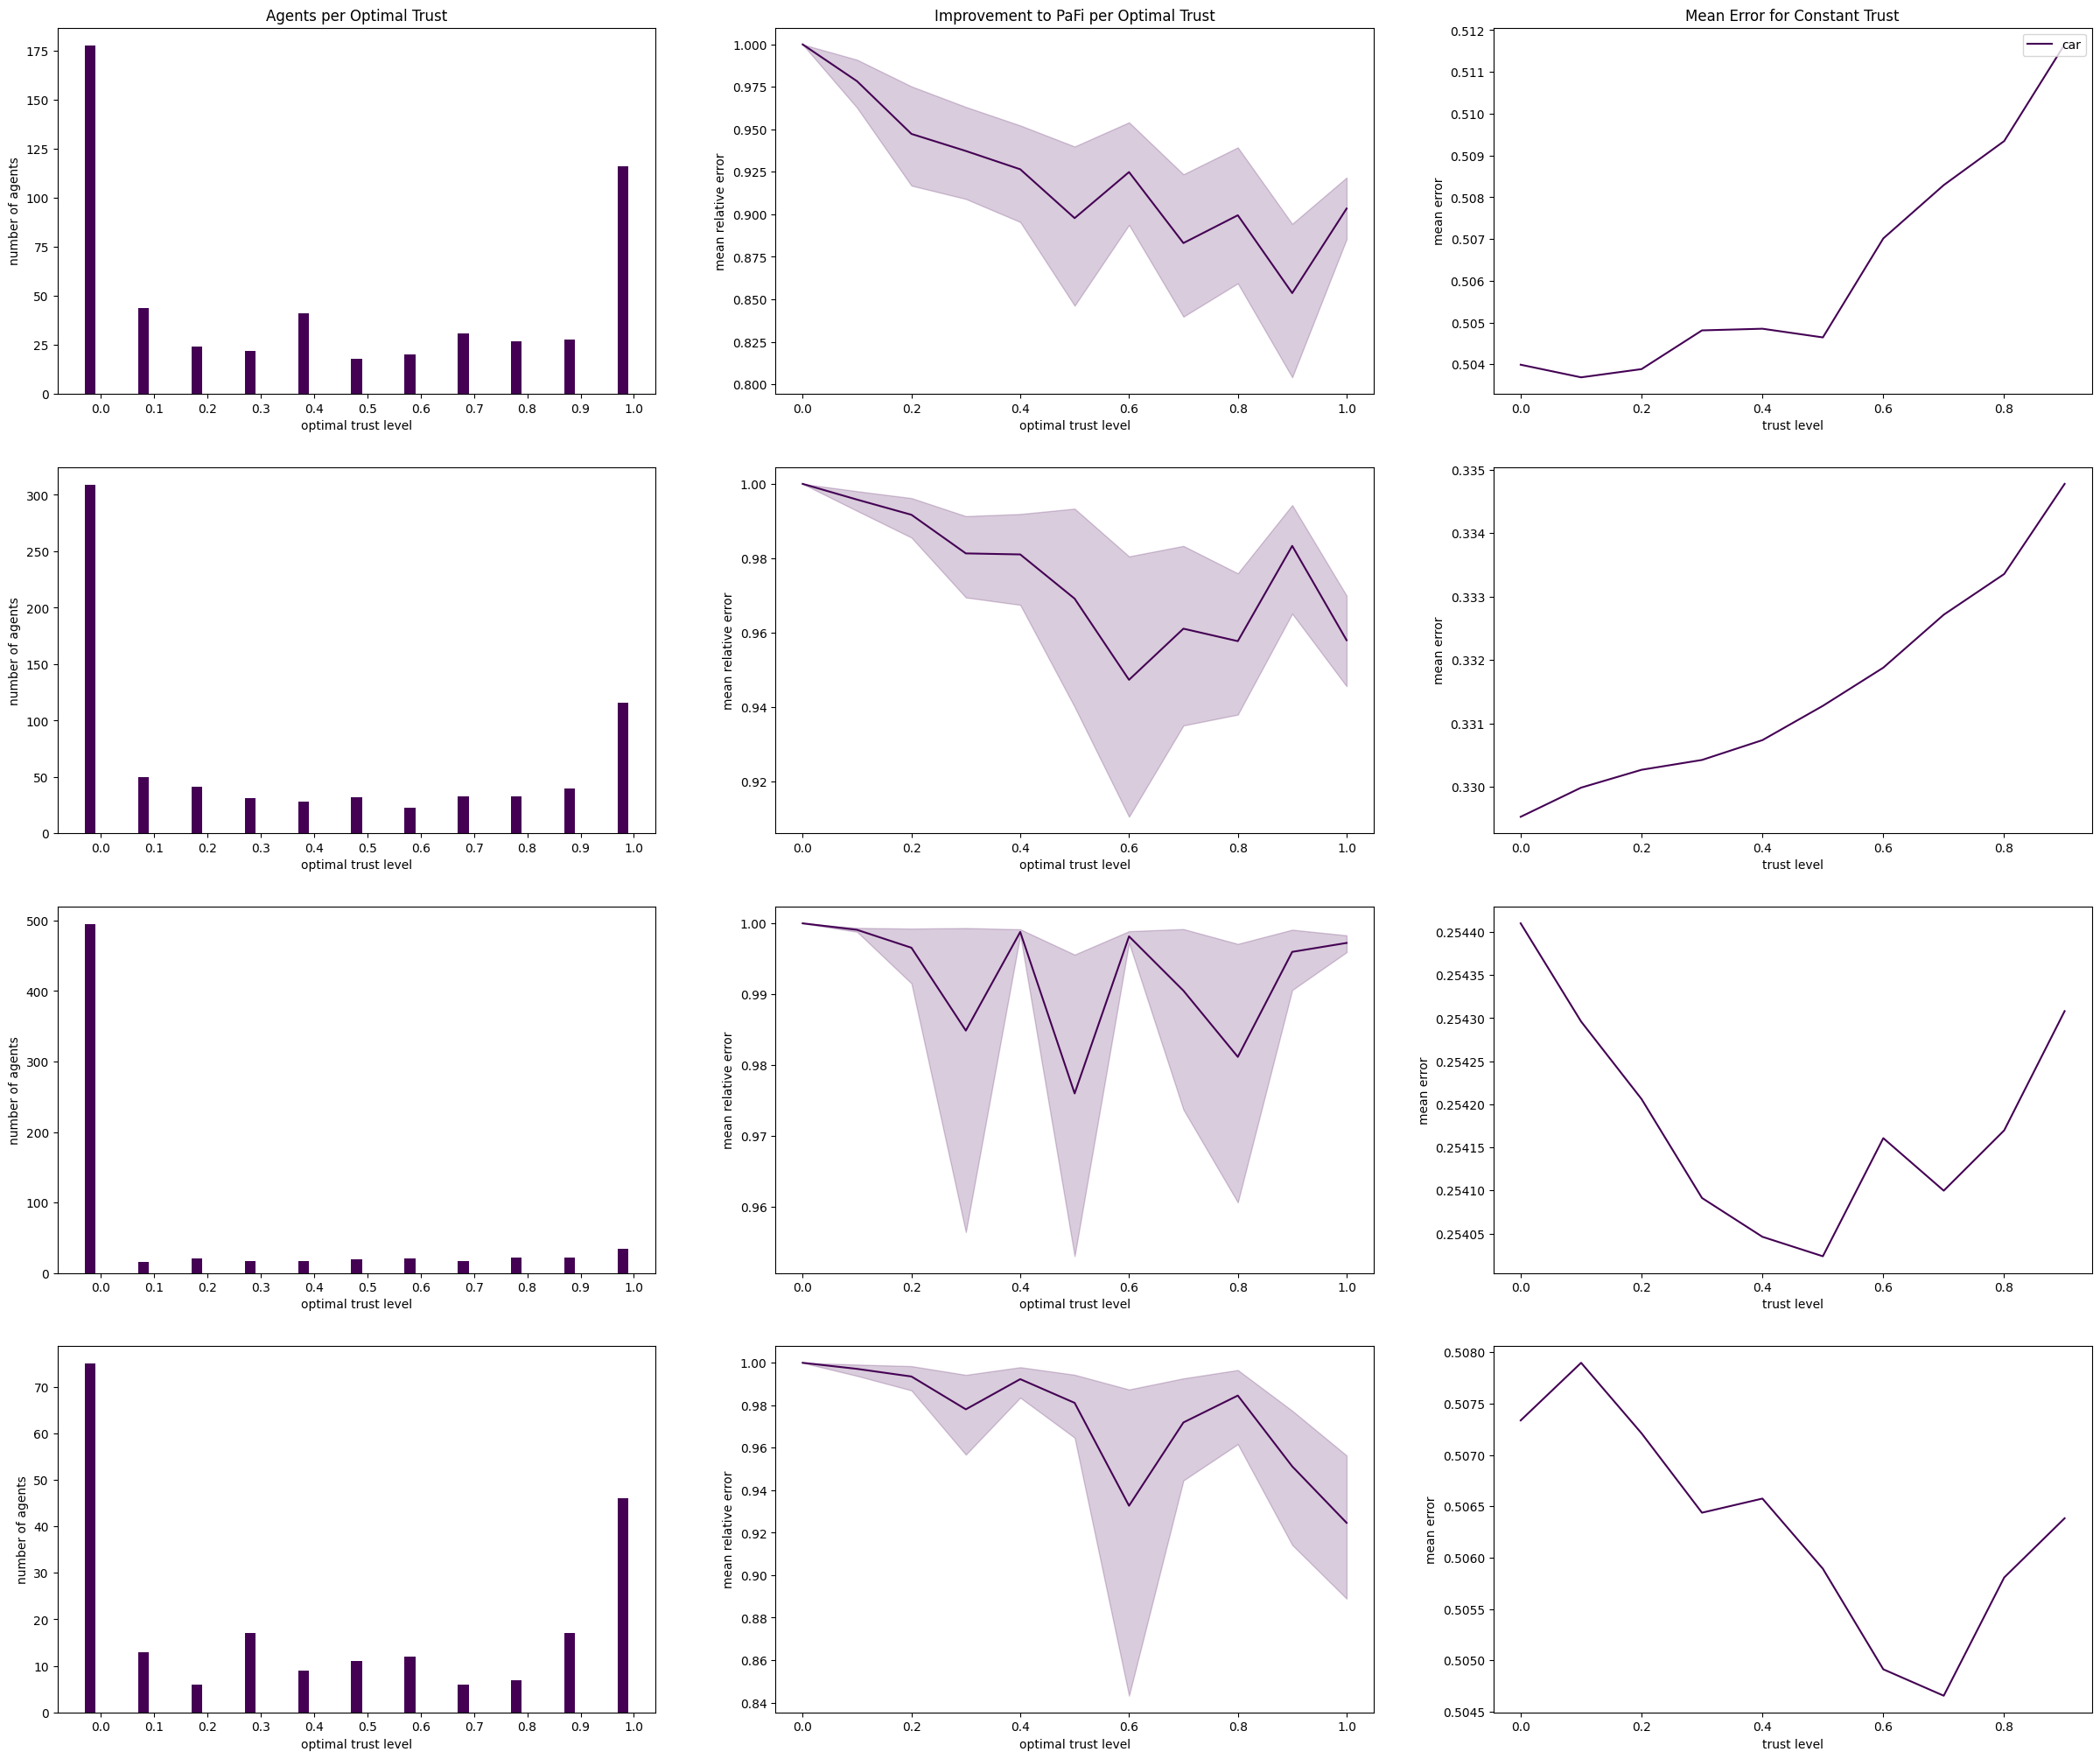

In [122]:

color_dict = {
    agent_type: matplotlib.colormaps["viridis"](i/2) for i, agent_type in enumerate(["car", "truck_bus", "bicycle"]) 
}

fig, ax = plt.subplots(4, 3, figsize=(30, 25))

for ax_i, env_index in enumerate(index_shortlist):
    data_list =  errors_reduced[env_index]
    ### histogram
    width = 0.2
    trust_num = 11
    x = np.arange(trust_num)

    hist_list = []
    for i, (logic_name, data) in enumerate(data_list.items()):
        offset = i * width
        x_ = x + offset
        hist_data_ = np.histogram(data[:, :, 0].argmin(axis=1), np.arange(data.shape[1] + 1) - 0.5)
        hist_list.append(hist_data_[0])
        
        ax[ax_i][0].bar(
            x_, 
            hist_data_[0], 
            width=width,
            label=logic_name,
            color=color_dict[logic_name],
        )
    
        # print(logic_name, hist_data_[0] / sum(hist_data_[0]))
    
        # ax[ax_i][0].hist(
        #     hist_data_[0],
        #     11,
        #     label=logic_name,
        #     color=color_dict[logic_name],
        #     density=True,
        # )

    ax[ax_i][0].set_ylabel("number of agents")
    ax[ax_i][0].set_xlabel("optimal trust level")
    # ax[ax_i][0].legend(loc='upper right')
    ax[ax_i][0].set_xticks(x+width, x / (trust_num - 1))

    

    ### error opt trust
    for logic_name, data in data_list.items():
        index_min = pd.DataFrame({
            "index": data[:, :, 0].argmin(axis=1) / (data.shape[1] - 1), 
            "relative error": data[:, :, 0].min(axis=1) / data[:, 0, 0],
            },
        )    
        sns.lineplot(data=index_min, x="index", y="relative error", ax=ax[ax_i][1], label=logic_name,
            color=color_dict[logic_name],)

    ax[ax_i][1].set_xlabel("optimal trust level")
    ax[ax_i][1].set_ylabel("mean relative error")
    ax[ax_i][1].get_legend().remove()

    
    for logic_name, data in data_list.items():
        index_min = pd.DataFrame({
            "index": np.arange(0, 1.1, 0.1,)[:-1], 
            "absolute error": data[:, :, 0].mean(axis=0)[:-1],
            },
        )    
        sns.lineplot(data=index_min, x="index", y="absolute error", ax=ax[ax_i][2], label=logic_name,
            color=color_dict[logic_name],)
        print(env_index, logic_name, data[:, :, 0].mean(axis=0) / data[:, :, 0].mean(axis=0)[0])
        
    ax[ax_i][2].set_xlabel("trust level")
    ax[ax_i][2].set_ylabel("mean error")
        
    


ax[0][0].title.set_text("Agents per Optimal Trust")
ax[0][1].title.set_text("Improvement to PaFi per Optimal Trust")
ax[0][2].title.set_text("Mean Error for Constant Trust")
ax[0][2].legend(loc='upper right')

for i in range(3):
    ax[i+1][2].get_legend().remove()

plt.savefig(output_folder / "figures" / "experiments" / "agent_landscape_trust.pdf")
plt.savefig(output_folder / "figures" / "experiments" / "agent_landscape_trust.svg")
    

### Per Sensor Error

In [103]:
errors_per_landscape_per_sensor_error = {}
for env_index in ["00"]:
    error_data = {}
    car_data = splits[env_index][2]
    agent_type = "car"
    for s_error in [0.5, 1, 1.5, 2, 3]:
        error_data[s_error] = evaluate_trust_ratio(
            car_data[car_data["class"] == agent_type],
            N=3000,
            sample_every=75,
            env_index=env_index,
            interpolator=DeltaGrid.load(promis_path / f"landscape-{env_index}-3s--trusted_{agent_type}.pkl").get_interpolator(),
            sensor_error=s_error,
        )
    errors_per_landscape_per_sensor_error[env_index] = error_data

/tmp/ipykernel_406506/3725617137.py:114: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


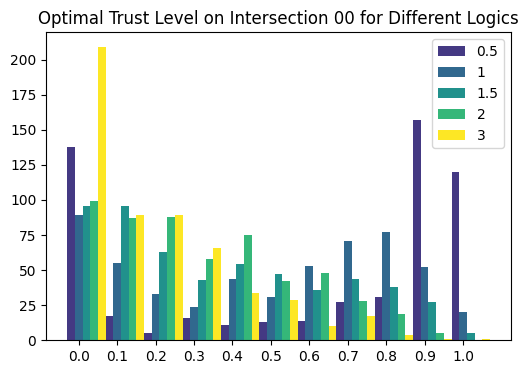

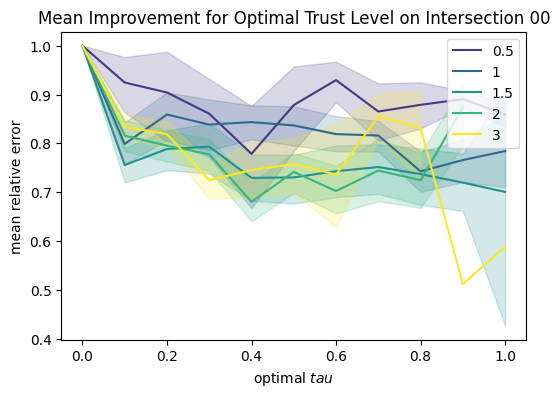

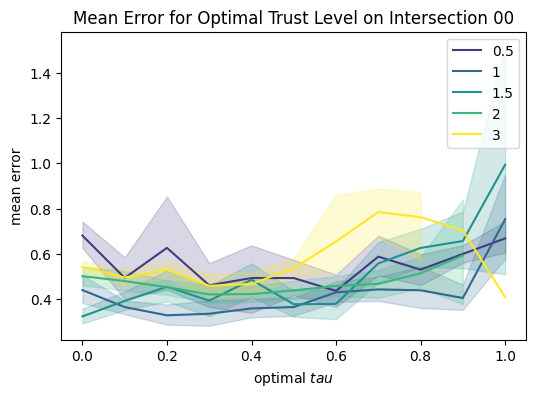

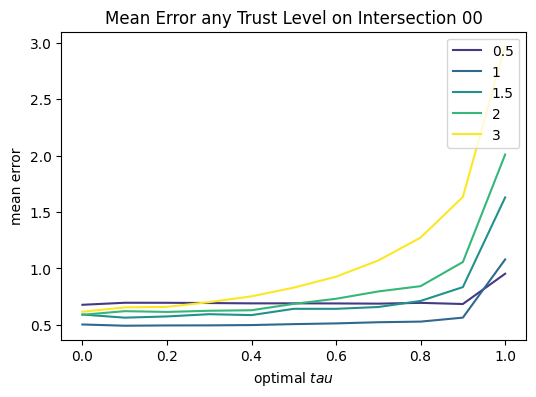

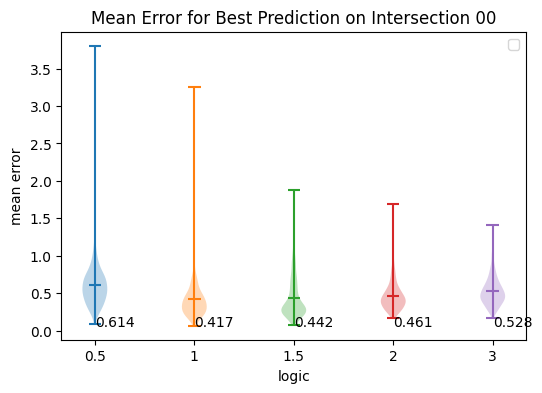

In [107]:

compare_opt_trust("00", errors_per_landscape_per_sensor_error["00"], False, "sensor_error", color_dict={
    i: matplotlib.colormaps["viridis"](i/3) for i in errors_per_landscape_per_sensor_error["00"].keys()
})

### Ablation

In [ ]:
ablation_index = "18"
ablation_type = "car"
ablation_baseline = f"""

road_correct(X) :-
    over(X, left_secondary);
    over(X, right_secondary);
    over(X, left_tertiary);
    over(X, right_tertiary);
    over(X, left_residential);
    over(X, right_residential);
    over(X, left_living_street);
    over(X, right_living_street);
    over(X, left_unclassified);
    over(X, right_unclassified).

landscape(X) :- 
    road_correct(X).
"""
build_landscape(uam18.origin, dimensions_per_index[ablation_index], ablation_baseline, "ablation", ablation_index, 3)

In [157]:
abl_interpol = CartesianCollection.load(promis_path / "landscape-00-3s--ablation.pkl").get_interpolator()
untrusted_interpol = CartesianCollection.load(promis_path / "landscape-00-3s--constitution.pkl").get_interpolator()
trusted_interpol = CartesianCollection.load(promis_path / "landscape-00-3s--trusted_car2.pkl").get_interpolator()

tracks = splits["00"][2]
tracks = tracks[tracks["class"] == ablation_type]

ablation_study = {
    "spatial baseline": evaluate_trust_ratio(
        tracks, 3000, sample_every=75, env_index="00", interpolator=abl_interpol 
    ),
    "unconfigured constitution": evaluate_trust_ratio(
        tracks, 3000, sample_every=75, env_index="00", interpolator=untrusted_interpol 
    ),
    "trust configured constitution": evaluate_trust_ratio(
        tracks, 3000, sample_every=75, env_index="00", interpolator=trusted_interpol 
    ),
}

/tmp/ipykernel_72874/3220091665.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


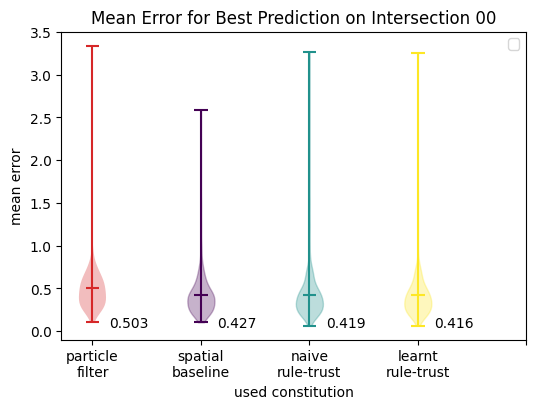

In [199]:

data_list = ablation_study
color_dict = {
    key: matplotlib.colormaps["viridis"](i / 2) for i, key in enumerate(ablation_study.keys())
}

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_title(f"Mean Error for Best Prediction on Intersection {'00'}")
ax.set_xlabel("used constitution")

for i, (logic_name, data) in enumerate(data_list.items()):
    parts = plt.violinplot(
        data[:, :, 0].min(axis=1), [2*(i + 1)],
        showmeans=True, showextrema=True, 
    )

    for pc in parts["bodies"]:
        pc.set_facecolor(color_dict[logic_name])
        pc.set_edgecolor(color_dict[logic_name])

    for pc in [parts["cbars"], parts["cmeans"], parts["cmaxes"], parts["cmins"]]:
        pc.set_facecolor(color_dict[logic_name])
        pc.set_edgecolor(color_dict[logic_name])
    
    ax.text(2*(i+1)+0.3, 0.05, str(data[:, :, 0].min(axis=1).mean())[:5])

start = 1

# for a particle filter, predictions should be the same for all logics
ax.violinplot(data[:, 0, 0], [0],
    showmeans=True, showextrema=True,
)
ax.text(0.3, 0.05, str(data[:, 0, 0].mean())[:5])
start = 0
    
labels = ["spatial\nbaseline", "naive\nrule-trust", "learnt\nrule-trust", ""]
ax.set_xticks([2*i for i in range(len(data_list) + 2)][start:], ["particle\nfilter", *labels][start:])
ax.set_ylabel("mean error")
ax.legend(loc='upper right')

plt.savefig(output_folder / "figures" / "experiments" / "ablation.pdf")